# 🧠 Sentence Memorability Experiment — Data Visualization

**Continuous Recognition Experiment** analysing how sentence memorability is affected by structure (Active / Passive voice) and constituent word memorability (High / Low for Subject and Object nouns).

### Sentence Types
| Log Code | Label | Subject | Object |
|----------|-------|---------|--------|
| `HH`  | HH | High | High |
| `HVL` | HL | High | Low  |
| `LVH` | LH | Low  | High |
| `LVL` | LL | Low  | Low  |

### Voice
- **Active** (`_A`) vs **Passive** (`_P`)

### Exclusion Criterion (per block)
> `#Correct_validation_IRs > (#Wrong_IRs / 2) + #Missed_validation_IRs`

## 1. Setup — Import Libraries & Configuration

In [1]:
import os
import glob
from collections import defaultdict
from itertools import combinations
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
%matplotlib inline

# ── Visual style ──
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "sans-serif",
})

# ── Constants ──
LOG_DIR     = "NewLogsAnonymized"
PLOT_DIR    = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

TYPE_MAP    = {"HH": "HH", "HVL": "HL", "LVH": "LH", "LVL": "LL"}
TYPE_ORDER  = ["HH", "HL", "LH", "LL"]
VOICE_ORDER = ["Active", "Passive"]
COND_ORDER  = [f"{t}_{v}" for t in TYPE_ORDER for v in VOICE_ORDER]

TYPE_PALETTE  = {"HH": "#2196F3", "HL": "#FF9800", "LH": "#4CAF50", "LL": "#E64A19"}
VOICE_PALETTE = {"Active": "#1565C0", "Passive": "#C62828"}
COND_PALETTE  = {
    "HH_Active": "#1976D2", "HH_Passive": "#64B5F6",
    "HL_Active": "#E65100", "HL_Passive": "#FFB74D",
    "LH_Active": "#2E7D32", "LH_Passive": "#81C784",
    "LL_Active": "#BF360C", "LL_Passive": "#FF8A65",
}

def mean_ci(series, confidence=0.95):
    """Return (mean, 95% CI half-width)."""
    n = len(series)
    m = series.mean()
    if n < 2:
        return m, 0
    se = series.sem()
    ci = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return m, ci

print("✅ Libraries loaded and configuration set.")

✅ Libraries loaded and configuration set.


## 2. Load & Parse Log Files

In [2]:
# ── Load all log files into an IMMUTABLE raw dataframe ──
frames = []
for fp in sorted(glob.glob(os.path.join(LOG_DIR, "*.log"))):
    frames.append(pd.read_csv(fp, na_values=["N/A", ""]))

df_raw = pd.concat(frames, ignore_index=True)      # ← original, NEVER modified
df_raw.columns = df_raw.columns.str.strip()

print(f"Rows loaded       : {len(df_raw):,}")
print(f"Participants found : {df_raw['participant_ID'].nunique()}")
print(f"\n✅ Original dataset stored in  df_raw  — this will NOT be modified.")
print(f"   All transformations happen on a working copy (df).")
df_raw.head(5)

Rows loaded       : 81,329
Participants found : 114

✅ Original dataset stored in  df_raw  — this will NOT be modified.
   All transformations happen on a working copy (df).


,participant_ID,Timestamp,Event,Stimulus,isTarget,isValidation,isRepeat,Button,Accuracy IR,Accuracy WR,Reaction_time_IR,Reaction_time_WR,CR_IR,CR_WR
0,232,1770218920752,Practice Sentence shown,HH_112_A,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,232,1770218923564,Practice IR pressed,HH_112_A,True,NaN,NaN,Spacebar,0.0,NaN,2812.0,NaN,NaN,NaN
2,232,1770218924911,Practice Sentence shown,HL_16_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,232,1770218930413,Practice Sentence shown,HH_116_A,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,232,1770218935915,Practice Sentence shown,HL_62_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 3. Exclusion Criteria — Block Validation

> **Rule:** A block is **excluded** if it fails the validation test:
>
> $$\text{Correct Validation IRs} > \frac{\text{Wrong IRs}}{2} + \text{Missed Validation IRs}$$
>
> Blocks that **do not** satisfy this inequality are dropped from all downstream memorability calculations.

⚠️ The original dataset (`df_raw`) is **never modified**. All filtering is applied dynamically on a working copy.

In [3]:
# ══════════════════════════════════════════════════════════════════════
# STEP A — Create a WORKING COPY and parse (original df_raw untouched)
# ══════════════════════════════════════════════════════════════════════
df = df_raw.copy()

# Boolean columns
for c in ("isTarget", "isValidation", "isRepeat"):
    df[c] = df[c].map({"true": True, True: True}).fillna(False)

# Numeric columns
for c in ("Accuracy IR", "Accuracy WR", "Reaction_time_IR", "Reaction_time_WR"):
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Parse stimulus codes
def parse_stimulus(stim):
    if pd.isna(stim):
        return None, None, None
    parts = stim.split("_")
    if len(parts) < 3:
        return None, None, None
    raw_type, sid, vcode = parts[0], parts[1], parts[2]
    stype = TYPE_MAP.get(raw_type)
    voice = {"A": "Active", "P": "Passive"}.get(vcode)
    return stype, sid, voice

parsed = df["Stimulus"].apply(parse_stimulus)
df["sent_type"] = [p[0] for p in parsed]
df["sent_id"]   = [p[1] for p in parsed]
df["voice"]     = [p[2] for p in parsed]

# ══════════════════════════════════════════════════════════════════════
# STEP B — Assign blocks  (practice = -1, experimental = 1, 2, 3)
# ══════════════════════════════════════════════════════════════════════
block_col = []
for _, grp in df.groupby("participant_ID", sort=False):
    blk = -1
    practice_done = False
    for ev in grp["Event"].values:
        if isinstance(ev, str) and ev.startswith("Practice"):
            block_col.append(-1)
            continue
        if not practice_done:
            practice_done = True
            blk = 1
        if isinstance(ev, str) and ev == "Rest Phase started":
            block_col.append(blk)
            blk += 1
            continue
        block_col.append(blk)

df["block"] = block_col
df_main = df[df["block"] > 0].copy()   # drop practice rows

def validate_block(bdf):
    """Apply the exclusion formula to one participant-block."""
    correct_val_ir = (bdf["Event"] == "Validation IR pressed").sum()
    wrong_ir       = (bdf["Event"] == "Validation Wrong IR pressed").sum()

    # Missed = validation repeats that were shown but never correctly detected
    val_repeats_shown = (
        (bdf["Event"] == "Sentence shown") &
        (bdf["isValidation"] == True) &
        (bdf["isRepeat"] == True)
    ).sum()
    missed_val_ir = max(0, val_repeats_shown - correct_val_ir)

    passes = correct_val_ir > (wrong_ir / 2) + missed_val_ir
    return passes, correct_val_ir, wrong_ir, missed_val_ir

validity_records = []
for (pid, blk), bdf in df_main.groupby(["participant_ID", "block"]):
    ok, c, w, m = validate_block(bdf)
    validity_records.append({
        "participant_ID": pid, "block": blk,
        "valid": ok,
        "correct_val_IRs": c, "wrong_IRs": w, "missed_val_IRs": m,
        "formula_LHS": c,
        "formula_RHS": (w / 2) + m,
    })

val_df = pd.DataFrame(validity_records)

# Tag each row in df_main with its block's validity (without altering df_raw)
df_main = df_main.merge(val_df[["participant_ID", "block", "valid"]],
                        on=["participant_ID", "block"], how="left")

# ══════════════════════════════════════════════════════════════════════
# STEP D — Filter to valid blocks only
# ══════════════════════════════════════════════════════════════════════
df_valid = df_main[df_main["valid"] == True].copy()

total_blocks    = len(val_df)
excluded_blocks = (~val_df["valid"]).sum()
valid_blocks    = total_blocks - excluded_blocks
parts_with_any  = val_df.groupby("participant_ID")["valid"].any()
excluded_parts  = (~parts_with_any).sum()
total_parts     = df["participant_ID"].nunique()

print("=" * 55)
print("  EXCLUSION CRITERIA RESULTS")
print("=" * 55)
print(f"  Original df_raw shape      : {df_raw.shape}  (UNCHANGED)")
print(f"  Working copy rows (no prac): {len(df_main):,}")
print(f"  ─────────────────────────────────────────────")
print(f"  Total participant-blocks   : {total_blocks}")
print(f"  ✅ Valid blocks             : {valid_blocks}  ({100*valid_blocks/total_blocks:.1f}%)")
print(f"  ❌ Excluded blocks          : {excluded_blocks}  ({100*excluded_blocks/total_blocks:.1f}%)")
print(f"  ─────────────────────────────────────────────")
print(f"  Total participants         : {total_parts}")
print(f"  Fully excluded (all blocks): {excluded_parts}")
print(f"  Remaining valid rows       : {len(df_valid):,}")
print("=" * 55)

  EXCLUSION CRITERIA RESULTS
  Original df_raw shape      : (81329, 14)  (UNCHANGED)
  Working copy rows (no prac): 76,060
  ─────────────────────────────────────────────
  Total participant-blocks   : 342
  ✅ Valid blocks             : 329  (96.2%)
  ❌ Excluded blocks          : 13  (3.8%)
  ─────────────────────────────────────────────
  Total participants         : 114
  Fully excluded (all blocks): 2
  Remaining valid rows       : 72,844


### 3a. Excluded Blocks — Detail Table
Show every block that **failed** the validation check, with the formula components.

In [4]:
# Show the excluded blocks with formula components
excluded_df = val_df[~val_df["valid"]].copy()
excluded_df["formula"] = (
    excluded_df.apply(
        lambda r: f"{r['correct_val_IRs']}  >  ({r['wrong_IRs']}/2) + {r['missed_val_IRs']}  =  {r['formula_RHS']:.1f}  →  FAIL",
        axis=1
    )
)
print(f"❌  {len(excluded_df)} block(s) excluded:\n")
display(excluded_df[["participant_ID", "block",
                     "correct_val_IRs", "wrong_IRs", "missed_val_IRs",
                     "formula_LHS", "formula_RHS", "formula"]]
        .rename(columns={"correct_val_IRs": "Correct Val IRs",
                         "wrong_IRs": "Wrong IRs",
                         "missed_val_IRs": "Missed Val IRs",
                         "formula_LHS": "LHS",
                         "formula_RHS": "RHS"})
        .reset_index(drop=True)
        .to_string(index=False))

# Confirm original is untouched
print(f"\n✅ Verification: df_raw shape is still {df_raw.shape} — original data unchanged.")

❌  13 block(s) excluded:



' participant_ID  block  Correct Val IRs  Wrong IRs  Missed Val IRs  LHS  RHS                             formula\n            245      1                7         10               3    7  8.0   7  >  (10/2) + 3  =  8.0  →  FAIL\n            258      1                7          8               3    7  7.0    7  >  (8/2) + 3  =  7.0  →  FAIL\n            271      1               10         25               0   10 12.5 10  >  (25/2) + 0  =  12.5  →  FAIL\n            271      2               10         21               0   10 10.5 10  >  (21/2) + 0  =  10.5  →  FAIL\n            271      3               10         27               0   10 13.5 10  >  (27/2) + 0  =  13.5  →  FAIL\n            294      1                9         18               1    9 10.0  9  >  (18/2) + 1  =  10.0  →  FAIL\n            297      2               10         20               0   10 10.0 10  >  (20/2) + 0  =  10.0  →  FAIL\n            299      1                7          9               3    7  7.5    7  >  (


✅ Verification: df_raw shape is still (81329, 14) — original data unchanged.


## 4. Compute Memorability Scores

- **Hit Rate (HR)** = Proportion of repeated targets correctly recognised (IR press)
- **False-Alarm Rate (FAR)** = Proportion of non-target filler sentences incorrectly flagged
- **Corrected Memorability** = HR − FAR

In [5]:
# ── 4a. Overall per participant-block metrics ──
pb_metrics = []
for (pid, blk), g in df_valid.groupby(["participant_ID", "block"]):
    repeats_shown = g[(g["Event"] == "Sentence shown") &
                      (g["isTarget"]) & (g["isRepeat"]) &
                      (g["sent_type"].notna())]
    hits = g[(g["Event"] == "IR pressed") &
             (g["isTarget"]) & (g["isRepeat"]) &
             (g["sent_type"].notna()) & (g["Accuracy IR"] == 1)]
    fa = g[(g["Event"] == "Validation Wrong IR pressed") &
           (g["sent_type"].notna())]
    first_shown = g[(g["Event"] == "Sentence shown") &
                    (g["isTarget"]) & (~g["isRepeat"]) &
                    (g["sent_type"].notna())]

    nr, nh, nf, nfirst = len(repeats_shown), len(hits), len(fa), len(first_shown)
    hr  = nh / nr if nr else 0
    far = nf / nfirst if nfirst else 0
    pb_metrics.append(dict(participant_ID=pid, block=blk,
                           hit_rate=hr, fa_rate=far, corrected=hr - far,
                           n_repeats=nr, n_hits=nh, n_fa=nf, n_first=nfirst))

pb_df = pd.DataFrame(pb_metrics)
overall_far = pb_df["fa_rate"].mean()

# ── 4b. Per condition (type × voice) per participant-block ──
cond_rows = []
for (pid, blk), g in df_valid.groupby(["participant_ID", "block"]):
    far = pb_df.loc[(pb_df["participant_ID"] == pid) &
                    (pb_df["block"] == blk), "fa_rate"].iloc[0]

    for st in TYPE_ORDER:
        for v in VOICE_ORDER:
            shown = g[(g["Event"] == "Sentence shown") &
                      (g["isTarget"]) & (g["isRepeat"]) &
                      (g["sent_type"] == st) & (g["voice"] == v)]
            hits = g[(g["Event"] == "IR pressed") &
                     (g["isTarget"]) & (g["isRepeat"]) &
                     (g["sent_type"] == st) & (g["voice"] == v) &
                     (g["Accuracy IR"] == 1)]
            wr = g[(g["Event"] == "WR pressed") &
                   (g["isTarget"]) & (g["isRepeat"]) &
                   (g["sent_type"] == st) & (g["voice"] == v)]
            rt = g[(g["Event"] == "IR pressed") &
                   (g["isTarget"]) & (g["isRepeat"]) &
                   (g["sent_type"] == st) & (g["voice"] == v) &
                   (g["Accuracy IR"] == 1)]["Reaction_time_IR"].dropna()

            ns = len(shown)
            if ns == 0:
                continue
            hr = len(hits) / ns
            wr_acc = wr["Accuracy WR"].mean() if len(wr) else np.nan
            mean_rt = rt.mean() if len(rt) else np.nan

            cond_rows.append(dict(
                participant_ID=pid, block=blk,
                sent_type=st, voice=v, condition=f"{st}_{v}",
                hit_rate=hr, fa_rate=far, corrected=hr - far,
                wr_accuracy=wr_acc, mean_rt_ir=mean_rt,
                n_shown=ns, n_hits=len(hits)))

cond_df = pd.DataFrame(cond_rows)

# ── Add Subject / Object memorability labels ──
subj_obj = {"HH": ("High", "High"), "HL": ("High", "Low"),
            "LH": ("Low", "High"),  "LL": ("Low", "Low")}
cond_df["subject_mem"] = cond_df["sent_type"].map(lambda t: subj_obj.get(t, (None, None))[0])
cond_df["object_mem"]  = cond_df["sent_type"].map(lambda t: subj_obj.get(t, (None, None))[1])

# ── 4c. Per-sentence memorability ──
sent_rows = []
target_repeat_shown = df_valid[(df_valid["Event"] == "Sentence shown") &
                               (df_valid["isTarget"]) & (df_valid["isRepeat"]) &
                               (df_valid["sent_type"].notna())]
target_ir = df_valid[(df_valid["Event"] == "IR pressed") &
                     (df_valid["isTarget"]) & (df_valid["isRepeat"]) &
                     (df_valid["sent_type"].notna())]

for (st, sid, v), grp_shown in target_repeat_shown.groupby(
        ["sent_type", "sent_id", "voice"]):
    n_total = len(grp_shown)
    grp_hits = target_ir[(target_ir["sent_type"] == st) &
                         (target_ir["sent_id"] == sid) &
                         (target_ir["voice"] == v) &
                         (target_ir["Accuracy IR"] == 1)]
    n_hits = len(grp_hits)
    hr = n_hits / n_total if n_total else 0
    sent_rows.append(dict(sent_type=st, sent_id=sid, voice=v,
                          condition=f"{st}_{v}",
                          hit_rate=hr, corrected=hr - overall_far,
                          n_presentations=n_total, n_hits=n_hits))

sent_df = pd.DataFrame(sent_rows)

print(f"Valid participant-blocks : {len(pb_df)}")
print(f"Condition-level obs     : {len(cond_df)}")
print(f"Unique sentences        : {len(sent_df)}")
print(f"Overall mean FAR        : {overall_far:.3f}")
print(f"Overall mean HR         : {pb_df['hit_rate'].mean():.3f}")
print(f"Overall corrected score : {pb_df['corrected'].mean():.3f}")

Valid participant-blocks : 329
Condition-level obs     : 2632
Unique sentences        : 392
Overall mean FAR        : 0.021
Overall mean HR         : 0.833
Overall corrected score : 0.812


---
## 5. Plot 1 — Data Overview (Exclusion Summary, Observations, Score Distribution)

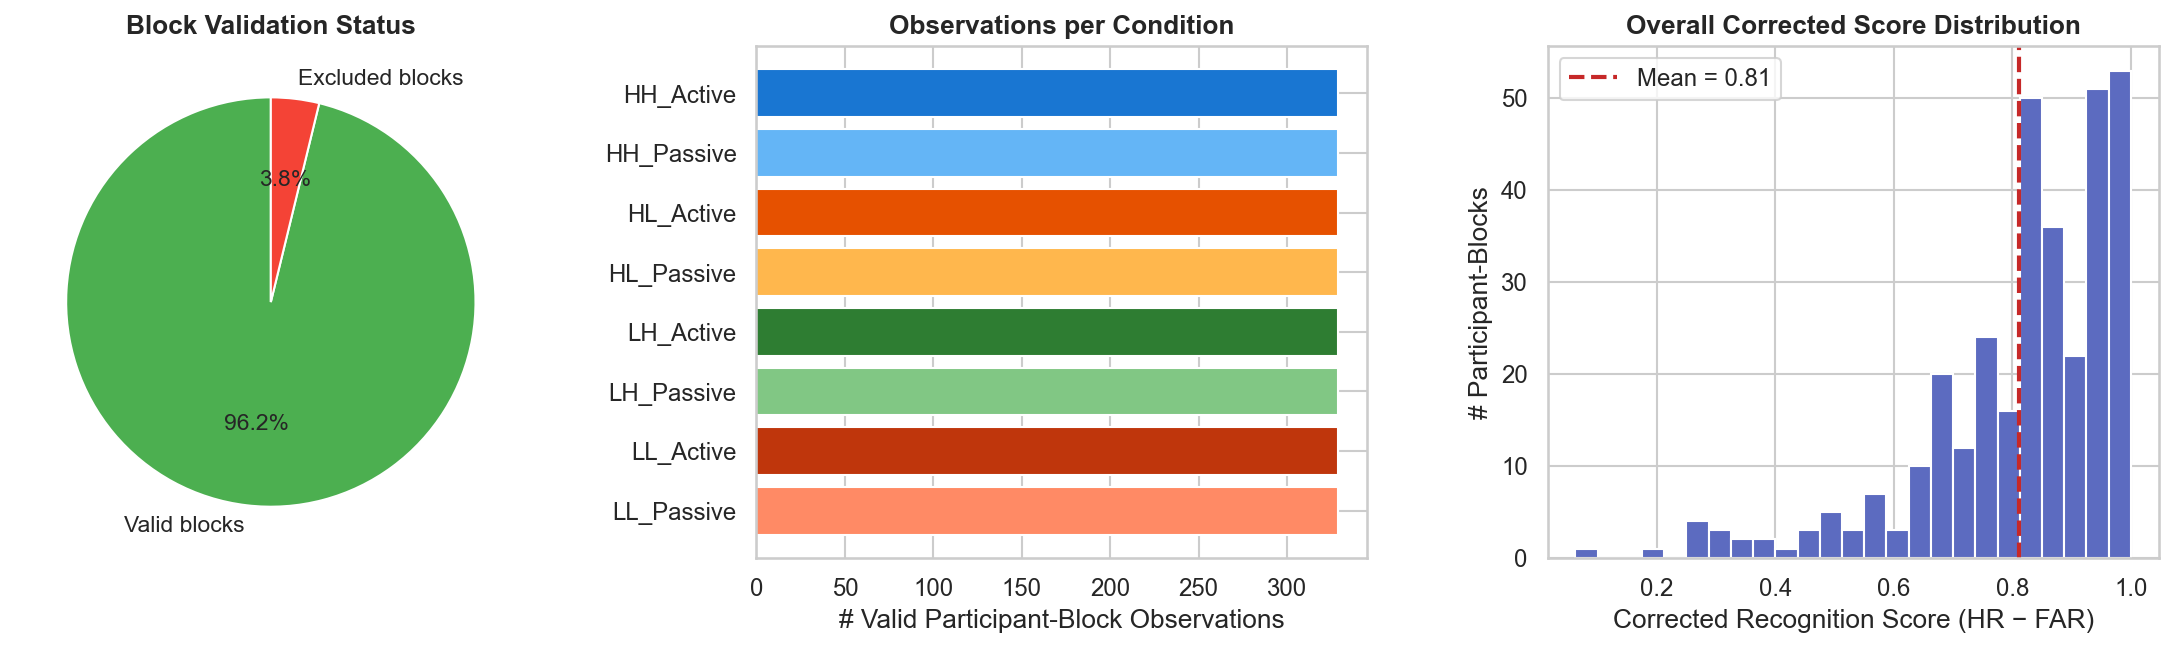

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) Block validity pie
labels_pie = ["Valid blocks", "Excluded blocks"]
sizes_pie  = [total_blocks - excluded_blocks, excluded_blocks]
colors_pie = ["#4CAF50", "#F44336"]
axes[0].pie(sizes_pie, labels=labels_pie, autopct="%1.1f%%",
            colors=colors_pie, startangle=90, textprops={"fontsize": 11})
axes[0].set_title("Block Validation Status", fontweight="bold")

# (b) Observations per condition
cond_counts = cond_df.groupby("condition").size().reindex(COND_ORDER)
bar_colors  = [COND_PALETTE[c] for c in COND_ORDER]
axes[1].barh(COND_ORDER, cond_counts.values, color=bar_colors)
axes[1].set_xlabel("# Valid Participant-Block Observations")
axes[1].set_title("Observations per Condition", fontweight="bold")
axes[1].invert_yaxis()

# (c) Corrected score distribution
axes[2].hist(pb_df["corrected"], bins=25, color="#5C6BC0", edgecolor="white")
axes[2].axvline(pb_df["corrected"].mean(), color="#C62828", ls="--", lw=2,
                label=f'Mean = {pb_df["corrected"].mean():.2f}')
axes[2].set_xlabel("Corrected Recognition Score (HR − FAR)")
axes[2].set_ylabel("# Participant-Blocks")
axes[2].set_title("Overall Corrected Score Distribution", fontweight="bold")
axes[2].legend()

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "01_data_overview.png"))
plt.show()

---
## 6. Plot 2 — Mean Corrected Memorability by Sentence Type (Bar Chart)

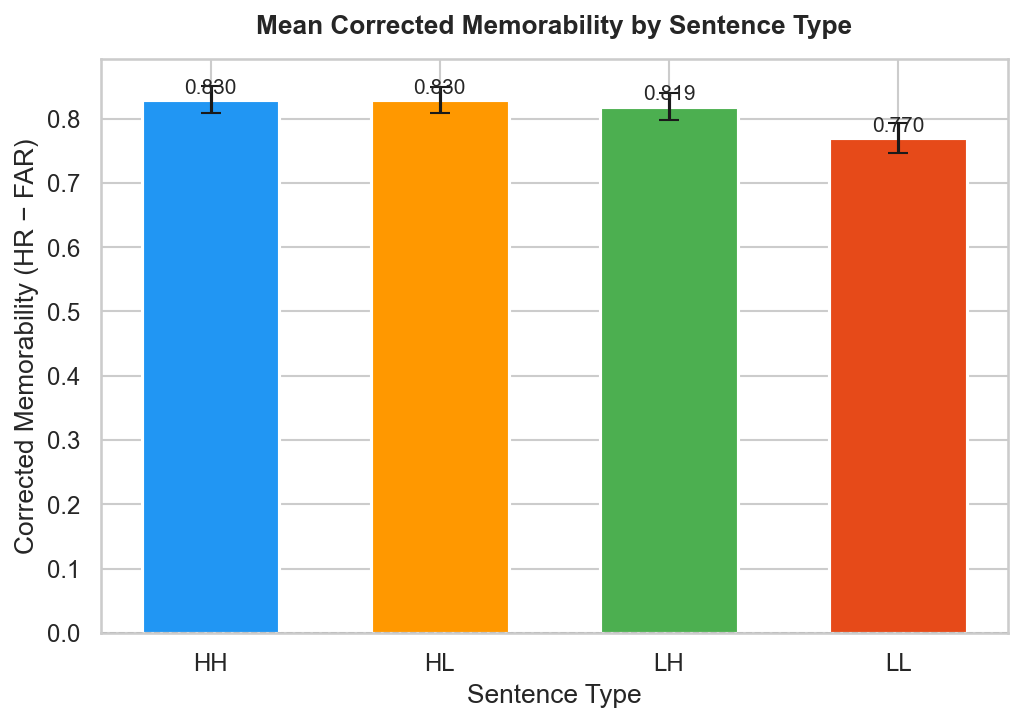

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
type_agg = cond_df.groupby("sent_type")["corrected"].agg(["mean", "sem", "count"]).reindex(TYPE_ORDER)

bars = ax.bar(TYPE_ORDER, type_agg["mean"],
              yerr=type_agg["sem"] * 1.96, capsize=5,
              color=[TYPE_PALETTE[t] for t in TYPE_ORDER],
              edgecolor="white", linewidth=1.5, width=0.6)
ax.set_ylabel("Corrected Memorability (HR − FAR)")
ax.set_xlabel("Sentence Type")
ax.set_title("Mean Corrected Memorability by Sentence Type", fontweight="bold", pad=12)
for b, t in zip(bars, TYPE_ORDER):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
            f"{type_agg.loc[t, 'mean']:.3f}", ha="center", fontsize=10)
ax.axhline(0, color="grey", ls="--", lw=0.8)

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "02_memorability_by_type.png"))
plt.show()

---
## 6b. Plot 2b — Recognition Accuracy by Sentence Type (ordered by noun memorability)

Each sentence has two key nouns (subject & object), each rated High or Low memorability.  
**LL** (0 high-mem nouns) → **LH** (high object) → **HL** (high subject) → **HH** (2 high-mem nouns).

> *"Sentences containing highly memorable nouns tend to have higher recognition accuracy."*

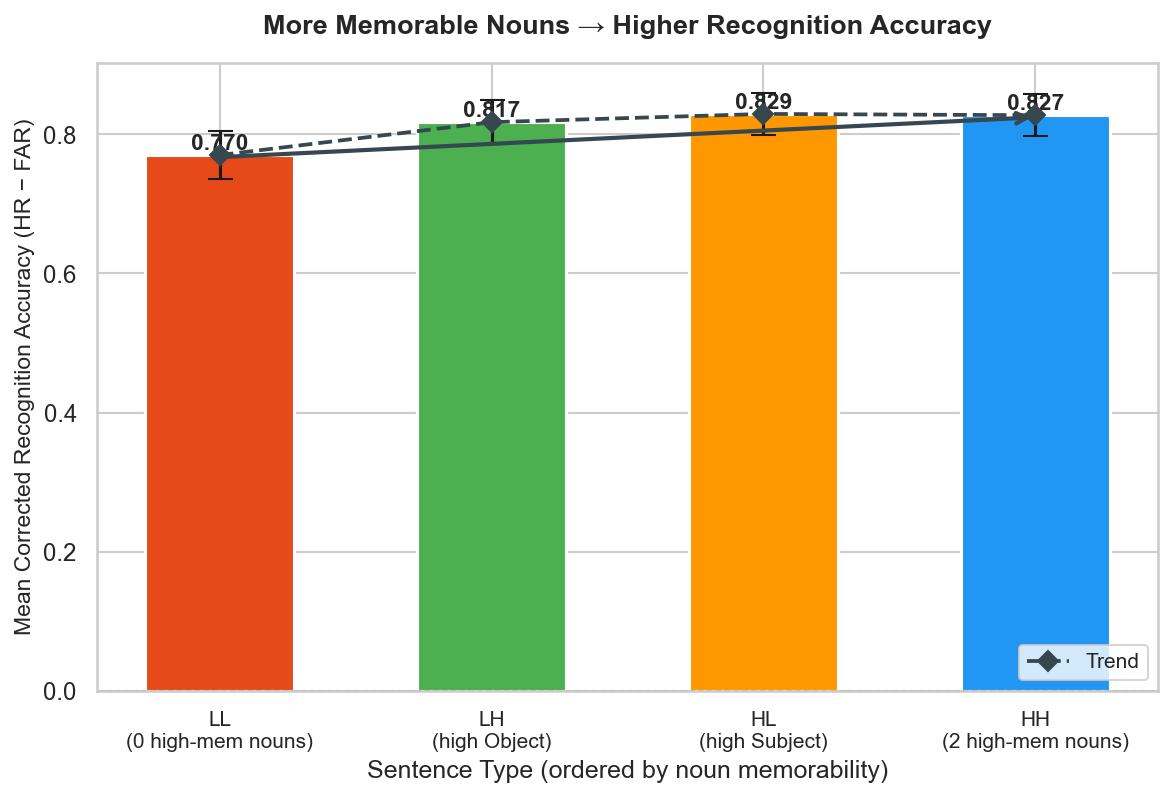


── Summary ──
  LL: mean = 0.7702  (n = 112 participants)
  LH: mean = 0.8174  (n = 112 participants)
  HL: mean = 0.8293  (n = 112 participants)
  HH: mean = 0.8275  (n = 112 participants)


In [8]:
# ── Aggregate per sentence type (keep HL and LH separate) ──
# Order: LL (0 high-mem) → LH (1: high object) → HL (1: high subject) → HH (2 high-mem)
type_order_mem = ["LL", "LH", "HL", "HH"]
noun_labels = {
    "LL": "LL\n(0 high-mem nouns)",
    "LH": "LH\n(high Object)",
    "HL": "HL\n(high Subject)",
    "HH": "HH\n(2 high-mem nouns)",
}
bar_colors_mem = ["#E64A19", "#4CAF50", "#FF9800", "#2196F3"]

# Participant-level means per sentence type
part_type = (cond_df.groupby(["participant_ID", "sent_type"])["corrected"]
             .mean().reset_index())
type_agg2 = (part_type.groupby("sent_type")["corrected"]
             .agg(["mean", "sem", "count"])
             .reindex(type_order_mem))

# ── Plot ──
fig, ax = plt.subplots(figsize=(8, 5.5))
x_pos = np.arange(len(type_order_mem))

bars = ax.bar(x_pos, type_agg2["mean"], yerr=type_agg2["sem"] * 1.96, capsize=6,
              color=bar_colors_mem, edgecolor="white", linewidth=1.5, width=0.55)

# Value labels
for bar, t in zip(bars, type_order_mem):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f"{type_agg2.loc[t, 'mean']:.3f}", ha="center", fontsize=11, fontweight="bold")

# Trend line connecting bar tops
ax.plot(x_pos, type_agg2["mean"].values, color="#37474F", ls="--", lw=1.8,
        marker="D", markersize=7, zorder=5, label="Trend")

ax.set_xticks(x_pos)
ax.set_xticklabels([noun_labels[t] for t in type_order_mem], fontsize=10)
ax.set_xlabel("Sentence Type (ordered by noun memorability)", fontsize=12)
ax.set_ylabel("Mean Corrected Recognition Accuracy (HR − FAR)", fontsize=11)
ax.set_title("More Memorable Nouns → Higher Recognition Accuracy",
             fontweight="bold", fontsize=13, pad=14)
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.legend(loc="lower right", fontsize=10)

# Annotation arrow
ax.annotate("", xy=(3, type_agg2.loc["HH", "mean"] - 0.003),
            xytext=(0, type_agg2.loc["LL", "mean"] - 0.003),
            arrowprops=dict(arrowstyle="->", color="#37474F", lw=2))

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "02b_accuracy_vs_noun_memorability.png"))
plt.show()

# Print summary
print("\n── Summary ──")
for t in type_order_mem:
    print(f"  {t}: mean = {type_agg2.loc[t, 'mean']:.4f}  "
          f"(n = {int(type_agg2.loc[t, 'count'])} participants)")

---
## 7. Plot 3 — Grouped Bar: Sentence Type × Voice

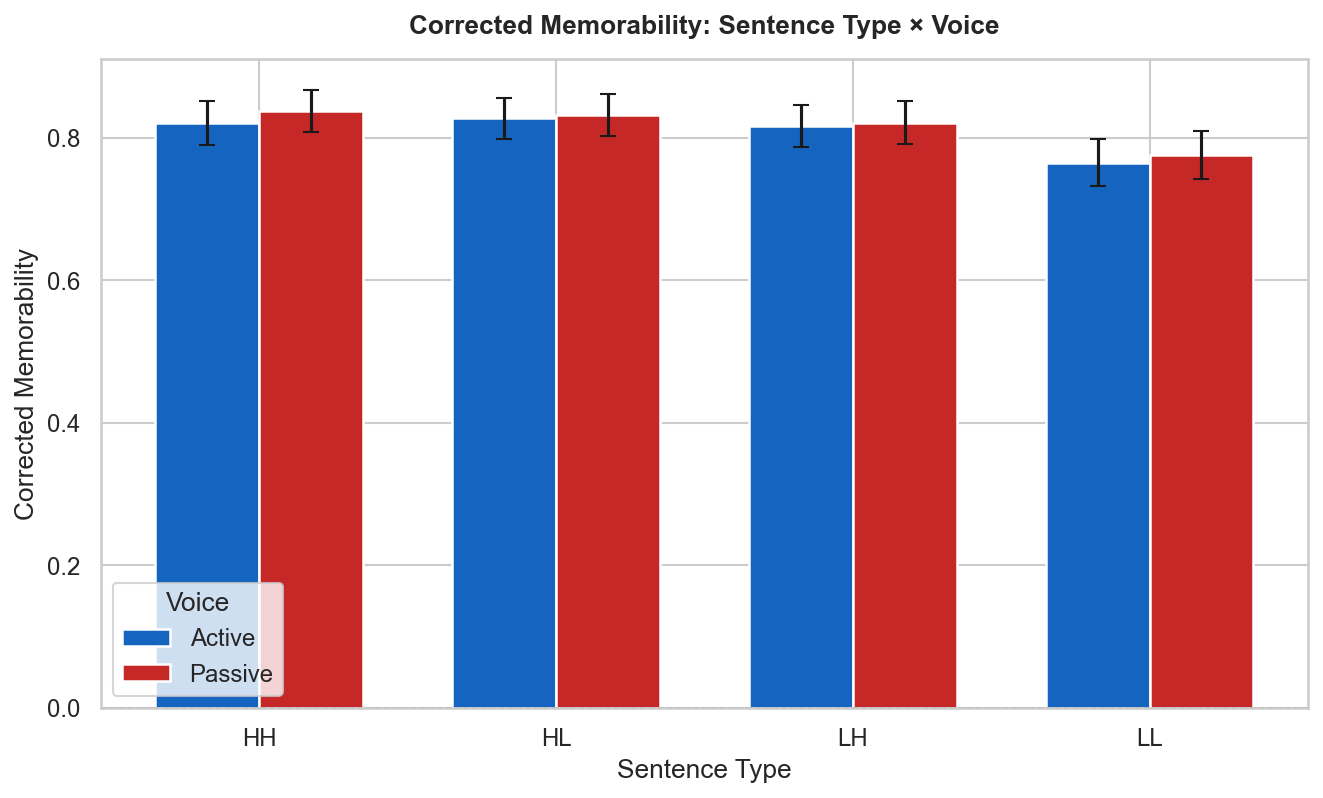

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(TYPE_ORDER))
width = 0.35

for i, v in enumerate(VOICE_ORDER):
    means, cis = [], []
    for t in TYPE_ORDER:
        sub = cond_df[(cond_df["sent_type"] == t) & (cond_df["voice"] == v)]
        m, ci = mean_ci(sub["corrected"])
        means.append(m); cis.append(ci)
    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width, yerr=cis, capsize=4,
           label=v, color=VOICE_PALETTE[v], edgecolor="white", linewidth=1.2)

ax.set_xticks(x); ax.set_xticklabels(TYPE_ORDER)
ax.set_ylabel("Corrected Memorability"); ax.set_xlabel("Sentence Type")
ax.set_title("Corrected Memorability: Sentence Type × Voice", fontweight="bold", pad=12)
ax.legend(title="Voice"); ax.axhline(0, color="grey", ls="--", lw=0.8)

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "03_type_x_voice_bar.png"))
plt.show()

---
## 8. Plot 4 — Box Plots: All 8 Conditions

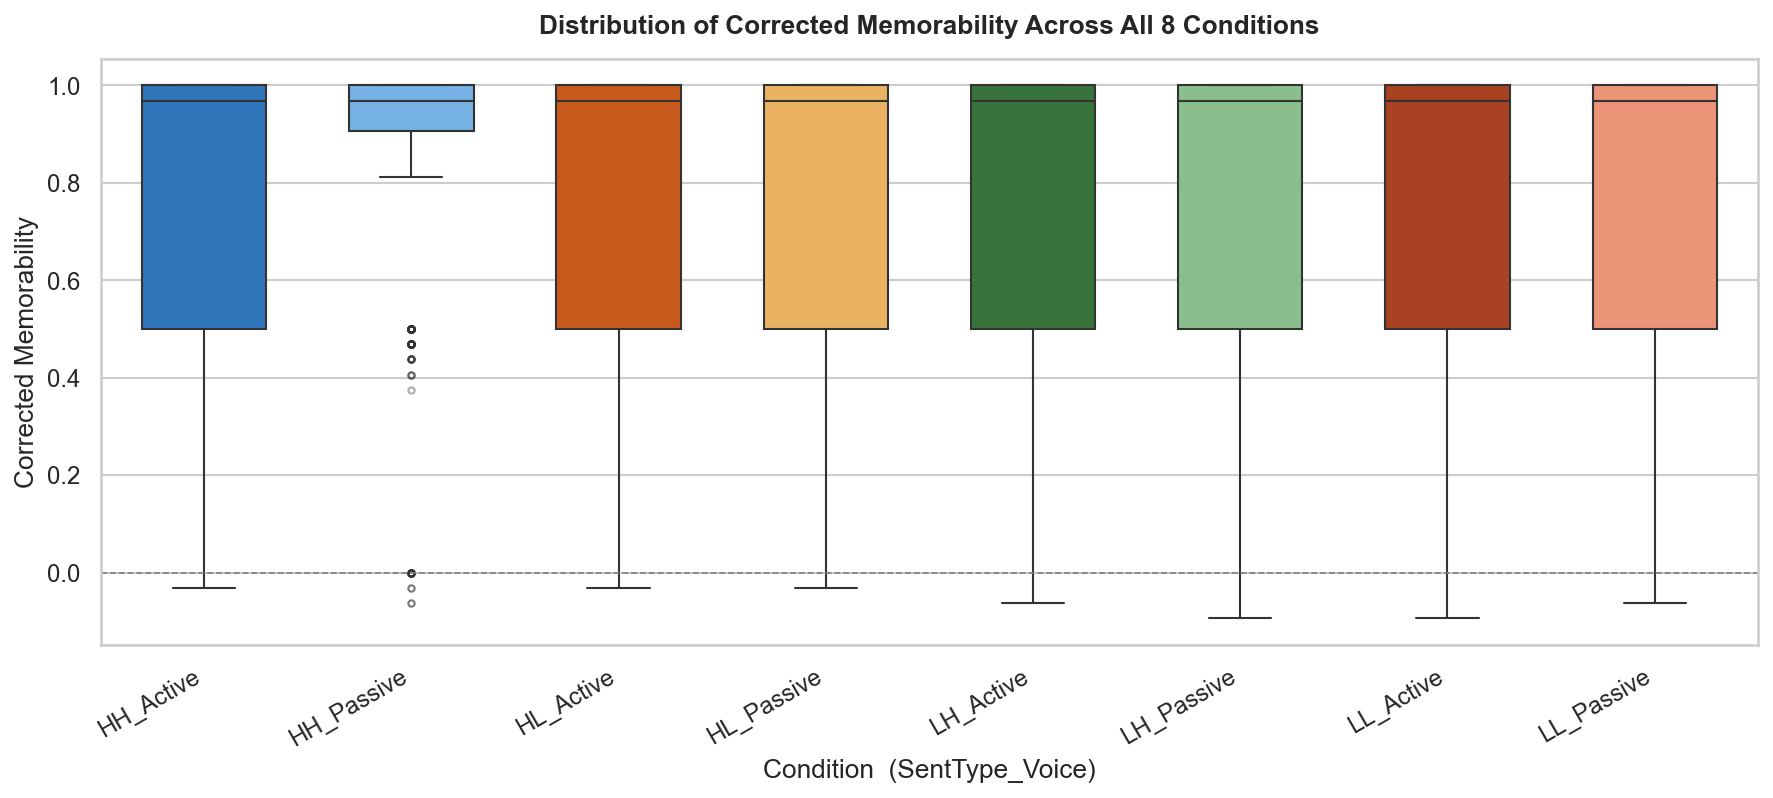

In [10]:
fig, ax = plt.subplots(figsize=(12, 5.5))
cond_df["condition_f"] = pd.Categorical(cond_df["condition"], categories=COND_ORDER, ordered=True)
palette_list = [COND_PALETTE[c] for c in COND_ORDER]

sns.boxplot(data=cond_df, x="condition_f", y="corrected",
            palette=palette_list, ax=ax, width=0.6,
            flierprops=dict(marker="o", markersize=3, alpha=0.4))
ax.set_xlabel("Condition  (SentType_Voice)")
ax.set_ylabel("Corrected Memorability")
ax.set_title("Distribution of Corrected Memorability Across All 8 Conditions", fontweight="bold", pad=12)
ax.axhline(0, color="grey", ls="--", lw=0.8)
plt.xticks(rotation=30, ha="right")

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "04_boxplots_all_conditions.png"))
plt.show()

---
## 9. Plot 5 — Violin Plots by Sentence Type

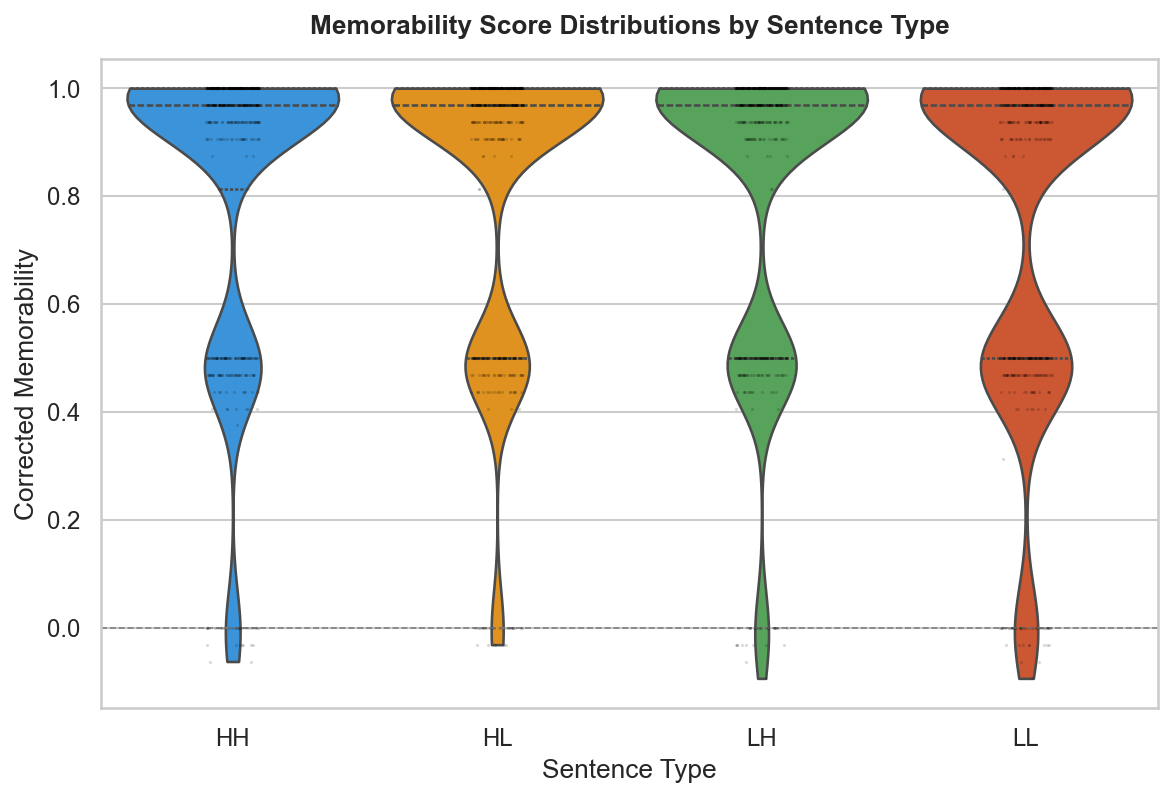

In [11]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.violinplot(data=cond_df, x="sent_type", y="corrected",
               order=TYPE_ORDER, palette=TYPE_PALETTE, inner="quartile", ax=ax, cut=0)
sns.stripplot(data=cond_df, x="sent_type", y="corrected",
              order=TYPE_ORDER, color="black", size=1.5, alpha=0.15, jitter=True, ax=ax)
ax.set_xlabel("Sentence Type"); ax.set_ylabel("Corrected Memorability")
ax.set_title("Memorability Score Distributions by Sentence Type", fontweight="bold", pad=12)
ax.axhline(0, color="grey", ls="--", lw=0.8)

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "05_violin_by_type.png"))
plt.show()

---
## 10. Plot 6 — Heatmap: Mean Corrected Memorability (Type × Voice)

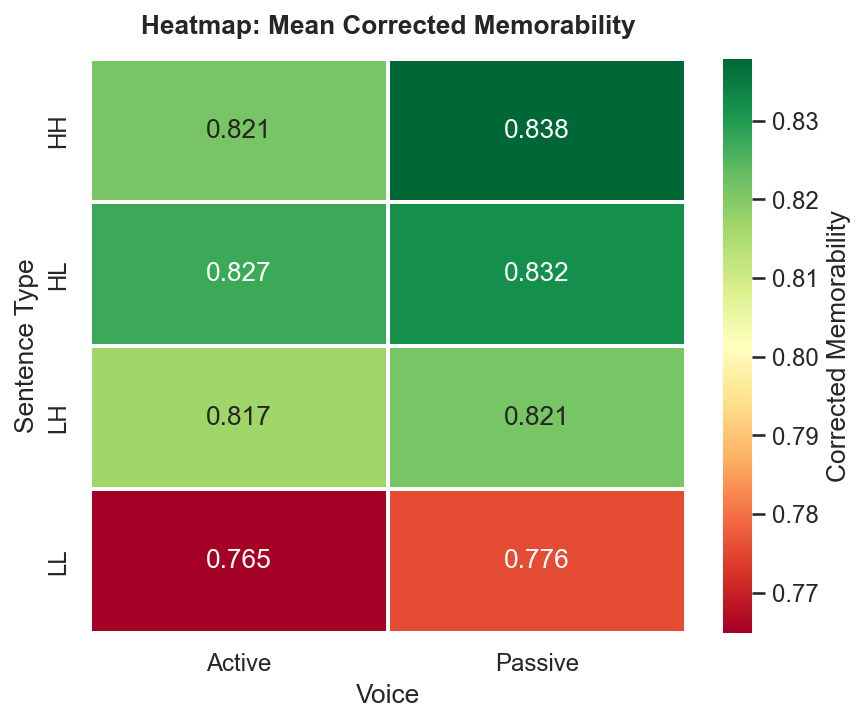

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
heat_data = (cond_df.groupby(["sent_type", "voice"])["corrected"]
             .mean().unstack("voice")
             .reindex(index=TYPE_ORDER, columns=VOICE_ORDER))

sns.heatmap(heat_data, annot=True, fmt=".3f", cmap="RdYlGn",
            linewidths=1, ax=ax, cbar_kws={"label": "Corrected Memorability"})
ax.set_title("Heatmap: Mean Corrected Memorability", fontweight="bold", pad=12)
ax.set_ylabel("Sentence Type"); ax.set_xlabel("Voice")

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "06_heatmap_type_voice.png"))
plt.show()

---
## 11. Plot 7 — Subject × Object Memorability Interaction Plot

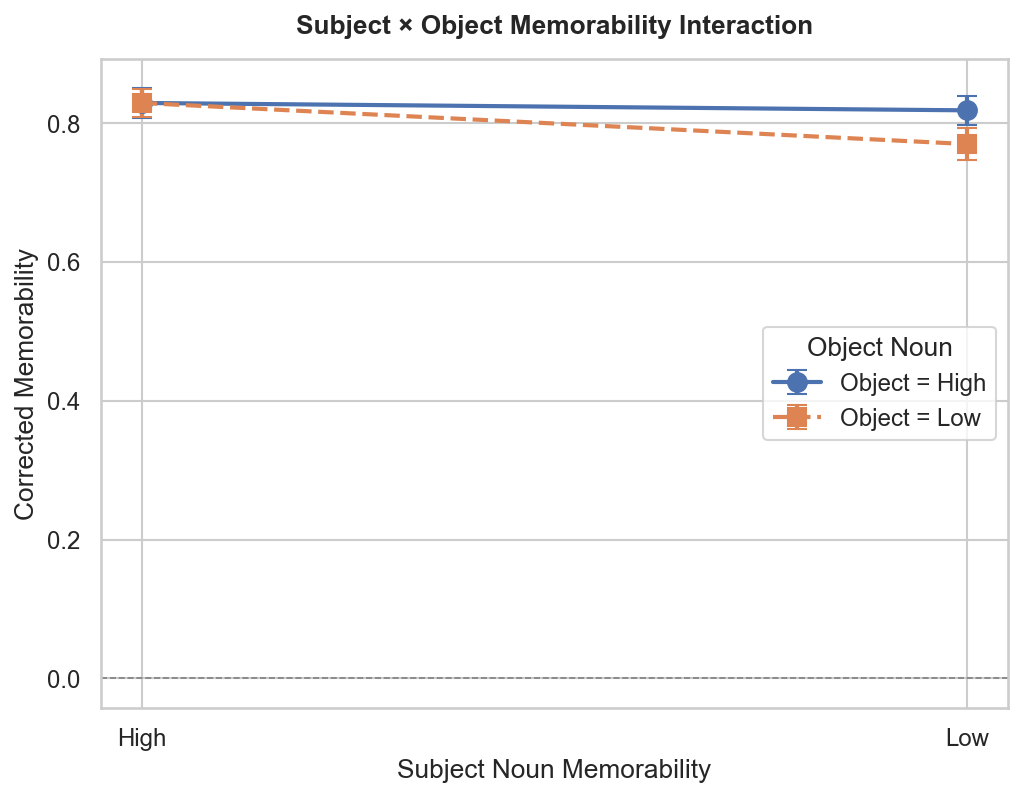

In [13]:
fig, ax = plt.subplots(figsize=(7, 5.5))

int_data = (cond_df.groupby(["subject_mem", "object_mem"])["corrected"]
            .agg(["mean", "sem"]).reset_index())

for obj_level, marker, ls in [("High", "o", "-"), ("Low", "s", "--")]:
    sub = int_data[int_data["object_mem"] == obj_level].sort_values("subject_mem")
    ax.errorbar(sub["subject_mem"], sub["mean"], yerr=sub["sem"] * 1.96,
                marker=marker, ls=ls, lw=2, markersize=9, capsize=5,
                label=f"Object = {obj_level}")

ax.set_xlabel("Subject Noun Memorability"); ax.set_ylabel("Corrected Memorability")
ax.set_title("Subject × Object Memorability Interaction", fontweight="bold", pad=12)
ax.legend(title="Object Noun"); ax.axhline(0, color="grey", ls="--", lw=0.8)

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "07_interaction_subj_obj.png"))
plt.show()

---
## Descriptive Statistics Table — Recognition Accuracy by Sentence Type

In [14]:
# ── Descriptive statistics: recognition accuracy (corrected) by sentence type ──
desc_table = (cond_df.groupby("sent_type")["corrected"]
              .agg(["mean", "std"])
              .reindex(TYPE_ORDER)
              .rename(columns={"mean": "Mean Accuracy", "std": "Std Dev"}))

desc_table.index.name = "Sentence Type"

# Display as a clean table
print("Descriptive statistics for recognition accuracy across sentence types\n")
print(desc_table.to_string(float_format=lambda x: f"{x:.4f}"))

# ── Also produce the LaTeX you can paste directly into your paper ──
latex_rows = []
for t in TYPE_ORDER:
    m = desc_table.loc[t, "Mean Accuracy"]
    s = desc_table.loc[t, "Std Dev"]
    latex_rows.append(f"    {t} & {m:.4f} & {s:.4f} \\\\")

latex_table = r"""\begin{table}[h]
\centering
\begin{tabular}{ccc}
\toprule
Sentence Type & Mean Accuracy & Std Dev \\
\midrule
""" + "\n".join(latex_rows) + r"""
\bottomrule
\end{tabular}
\caption{Descriptive statistics for recognition accuracy across sentence types}
\label{tab:desc}
\end{table}"""

print("\n\n── LaTeX (copy-paste ready) ──\n")
print(latex_table)

Descriptive statistics for recognition accuracy across sentence types

               Mean Accuracy  Std Dev
Sentence Type                        
HH                    0.8295   0.2782
HL                    0.8295   0.2665
LH                    0.8189   0.2760
LL                    0.7702   0.3073


── LaTeX (copy-paste ready) ──

\begin{table}[h]
\centering
\begin{tabular}{ccc}
\toprule
Sentence Type & Mean Accuracy & Std Dev \\
\midrule
    HH & 0.8295 & 0.2782 \\
    HL & 0.8295 & 0.2665 \\
    LH & 0.8189 & 0.2760 \\
    LL & 0.7702 & 0.3073 \\
\bottomrule
\end{tabular}
\caption{Descriptive statistics for recognition accuracy across sentence types}
\label{tab:desc}
\end{table}


---
## Recognition Accuracy (%) by Voice Type — Active vs Passive

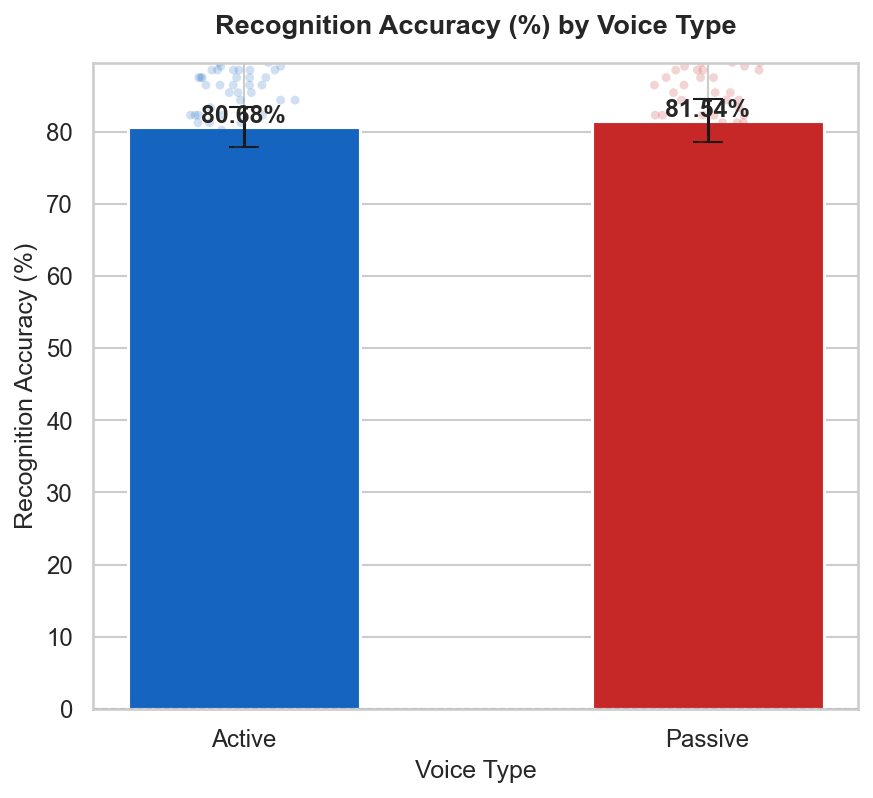


── Summary ──
  Active  : 80.68%  (±2.74% 95% CI, n = 112 participants)
  Passive : 81.54%  (±2.97% 95% CI, n = 112 participants)

  Difference (Active − Passive): -0.86 pp


In [15]:
# ── Recognition Accuracy (%) by Voice Type ──
# Participant-level: average corrected score per voice, then aggregate
part_voice = (cond_df.groupby(["participant_ID", "voice"])["corrected"]
              .mean().reset_index())
voice_agg = part_voice.groupby("voice")["corrected"].agg(["mean", "sem", "count"]).reindex(VOICE_ORDER)

# Convert to percentage
voice_agg["mean_pct"] = voice_agg["mean"] * 100
voice_agg["sem_pct"]  = voice_agg["sem"] * 100

fig, ax = plt.subplots(figsize=(6, 5.5))

bars = ax.bar(VOICE_ORDER, voice_agg["mean_pct"],
              yerr=voice_agg["sem_pct"] * 1.96, capsize=7,
              color=[VOICE_PALETTE[v] for v in VOICE_ORDER],
              edgecolor="white", linewidth=1.5, width=0.5)

# Value labels on bars
for bar, v in zip(bars, VOICE_ORDER):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.6,
            f"{voice_agg.loc[v, 'mean_pct']:.2f}%",
            ha="center", fontsize=12, fontweight="bold")

ax.set_ylabel("Recognition Accuracy (%)", fontsize=12)
ax.set_xlabel("Voice Type", fontsize=12)
ax.set_title("Recognition Accuracy (%) by Voice Type", fontweight="bold", fontsize=13, pad=14)
ax.set_ylim(0, max(voice_agg["mean_pct"]) + 8)
ax.axhline(0, color="grey", ls="--", lw=0.8)

# Individual participant dots (jittered)
for i, v in enumerate(VOICE_ORDER):
    sub = part_voice[part_voice["voice"] == v]["corrected"] * 100
    jitter = np.random.default_rng(42).uniform(-0.12, 0.12, size=len(sub))
    ax.scatter(np.full(len(sub), i) + jitter, sub, color=VOICE_PALETTE[v],
               alpha=0.2, s=18, zorder=2, edgecolors="none")

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "08_accuracy_by_voice.png"))
plt.show()

# Print summary
diff = voice_agg.loc["Active", "mean_pct"] - voice_agg.loc["Passive", "mean_pct"]
print(f"\n── Summary ──")
for v in VOICE_ORDER:
    print(f"  {v:8s}: {voice_agg.loc[v, 'mean_pct']:.2f}%  "
          f"(±{voice_agg.loc[v, 'sem_pct'] * 1.96:.2f}% 95% CI, "
          f"n = {int(voice_agg.loc[v, 'count'])} participants)")
print(f"\n  Difference (Active − Passive): {diff:+.2f} pp")

---
## 12. IR Memorability (Identical Recognition)

**IR = Identical Recognition** — measures how often participants correctly recognise a sentence that is **exactly the same** as one they saw earlier (surface-level / verbatim memory).

$$\text{IR Memorability} = \frac{\text{Correct identical recognitions}}{\text{Total identical repetitions}}$$

Corrected IR Memorability subtracts the false-alarm rate:  $\; M_{IR} = HR_{IR} - FAR$

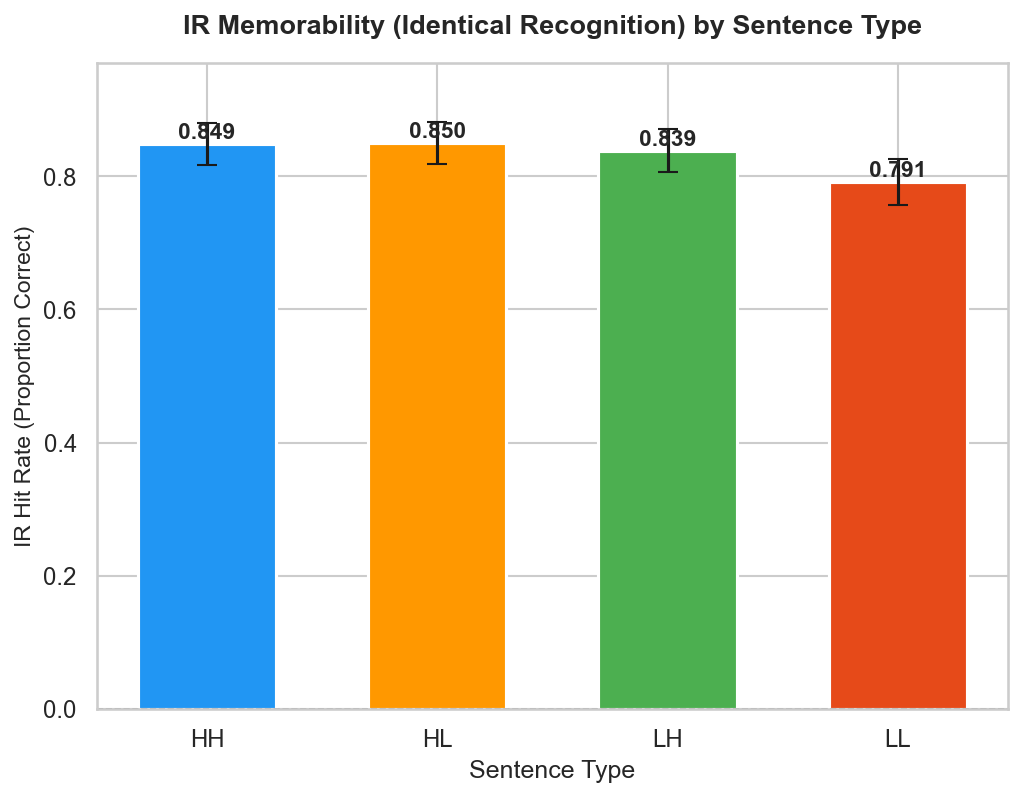


── IR Memorability by Sentence Type ──
  HH: mean = 0.8486  (±0.0310 95% CI, n = 112)
  HL: mean = 0.8504  (±0.0312 95% CI, n = 112)
  LH: mean = 0.8385  (±0.0319 95% CI, n = 112)
  LL: mean = 0.7913  (±0.0349 95% CI, n = 112)


In [16]:
# ══════════════════════════════════════════════════════════════════════
# 12a. IR Memorability — Bar Chart by Sentence Type
# ══════════════════════════════════════════════════════════════════════

# Participant-level IR means per sentence type
part_ir_type = (cond_df.groupby(["participant_ID", "sent_type"])["hit_rate"]
                .mean().reset_index())
ir_type_agg = (part_ir_type.groupby("sent_type")["hit_rate"]
               .agg(["mean", "sem", "count"]).reindex(TYPE_ORDER))

fig, ax = plt.subplots(figsize=(7, 5.5))
bars = ax.bar(TYPE_ORDER, ir_type_agg["mean"],
              yerr=ir_type_agg["sem"] * 1.96, capsize=5,
              color=[TYPE_PALETTE[t] for t in TYPE_ORDER],
              edgecolor="white", linewidth=1.5, width=0.6)

for b, t in zip(bars, TYPE_ORDER):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.008,
            f"{ir_type_agg.loc[t, 'mean']:.3f}", ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("IR Hit Rate (Proportion Correct)", fontsize=11)
ax.set_xlabel("Sentence Type", fontsize=12)
ax.set_title("IR Memorability (Identical Recognition) by Sentence Type",
             fontweight="bold", fontsize=13, pad=14)
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.set_ylim(0, min(1.0, ir_type_agg["mean"].max() + 0.12))

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "09_ir_memorability_by_type.png"))
plt.show()

# ── Print summary ──
print("\n── IR Memorability by Sentence Type ──")
for t in TYPE_ORDER:
    print(f"  {t}: mean = {ir_type_agg.loc[t, 'mean']:.4f}  "
          f"(±{ir_type_agg.loc[t, 'sem'] * 1.96:.4f} 95% CI, "
          f"n = {int(ir_type_agg.loc[t, 'count'])})")

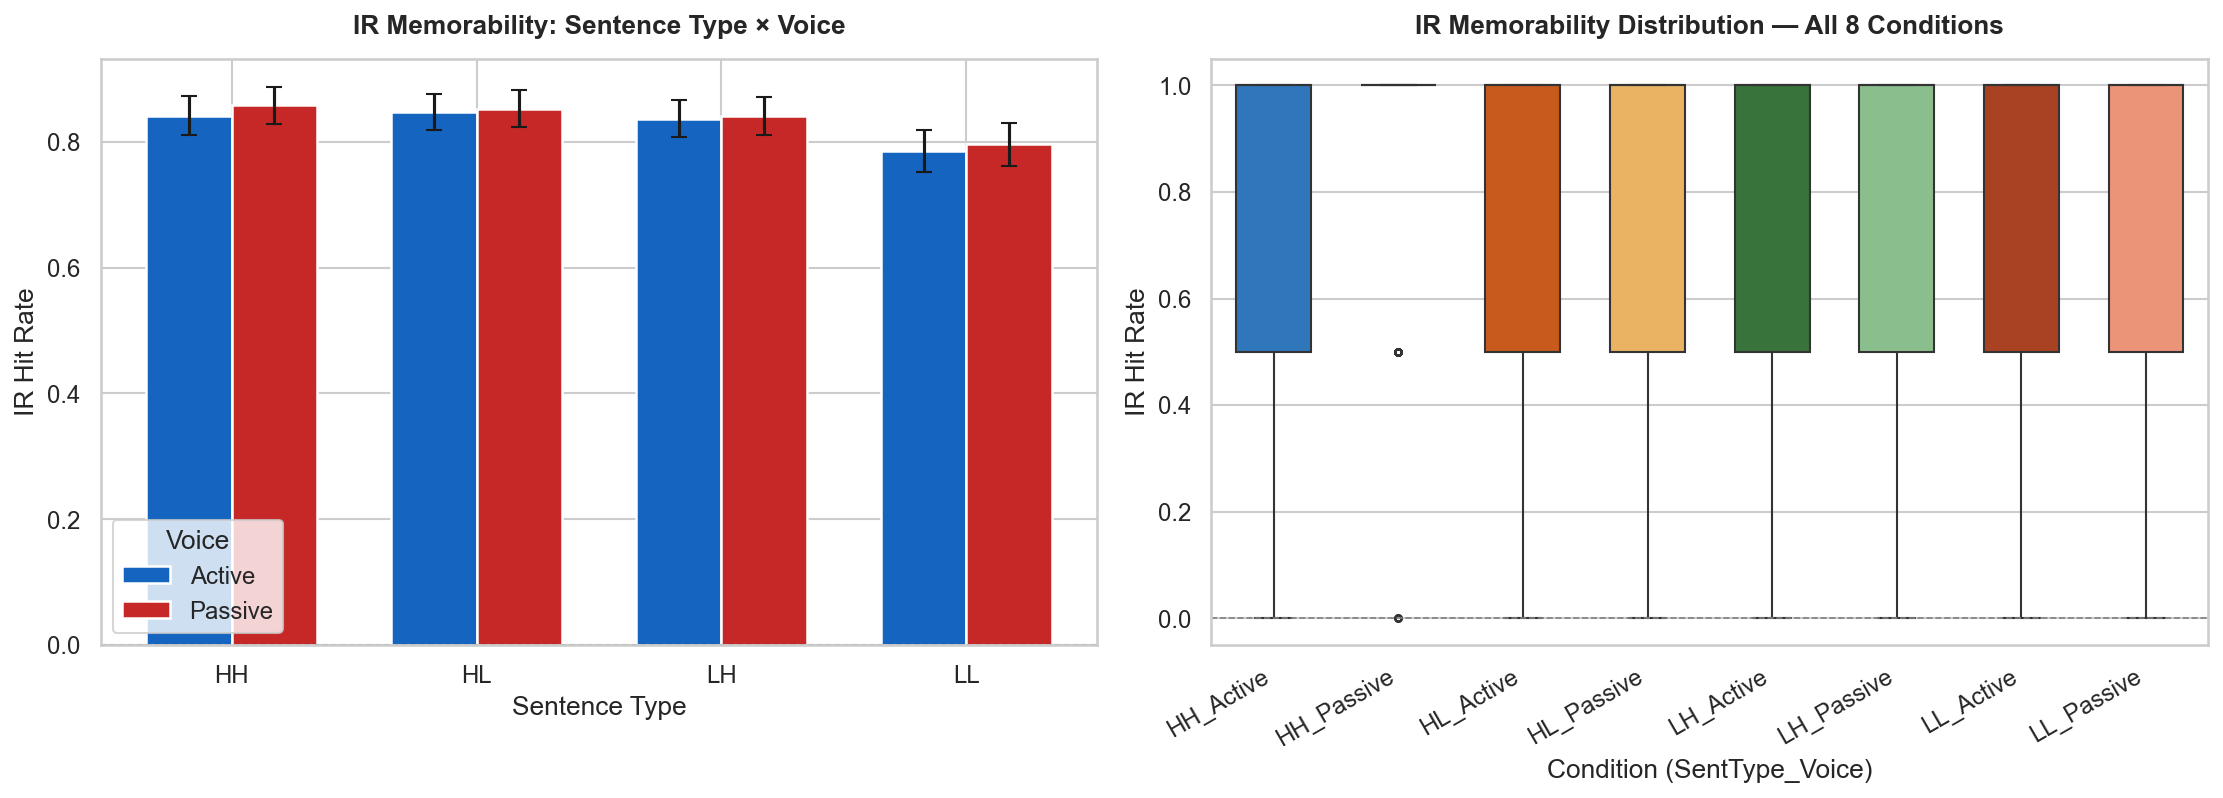

In [17]:
# ══════════════════════════════════════════════════════════════════════
# 12b. IR Memorability — Grouped Bar: Sentence Type × Voice
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── Left: Grouped bar (Type × Voice) ──
ax = axes[0]
x = np.arange(len(TYPE_ORDER))
width = 0.35

for i, v in enumerate(VOICE_ORDER):
    means, cis = [], []
    for t in TYPE_ORDER:
        sub = cond_df[(cond_df["sent_type"] == t) & (cond_df["voice"] == v)]
        m, ci = mean_ci(sub["hit_rate"])
        means.append(m); cis.append(ci)
    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width, yerr=cis, capsize=4,
           label=v, color=VOICE_PALETTE[v], edgecolor="white", linewidth=1.2)

ax.set_xticks(x); ax.set_xticklabels(TYPE_ORDER)
ax.set_ylabel("IR Hit Rate"); ax.set_xlabel("Sentence Type")
ax.set_title("IR Memorability: Sentence Type × Voice", fontweight="bold", pad=12)
ax.legend(title="Voice"); ax.axhline(0, color="grey", ls="--", lw=0.8)

# ── Right: Boxplot across all 8 conditions ──
ax = axes[1]
cond_df["condition_f"] = pd.Categorical(cond_df["condition"], categories=COND_ORDER, ordered=True)
palette_list = [COND_PALETTE[c] for c in COND_ORDER]
sns.boxplot(data=cond_df, x="condition_f", y="hit_rate",
            palette=palette_list, ax=ax, width=0.6,
            flierprops=dict(marker="o", markersize=3, alpha=0.4))
ax.set_xlabel("Condition (SentType_Voice)")
ax.set_ylabel("IR Hit Rate")
ax.set_title("IR Memorability Distribution — All 8 Conditions", fontweight="bold", pad=12)
ax.axhline(0, color="grey", ls="--", lw=0.8)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "10_ir_type_x_voice.png"))
plt.show()

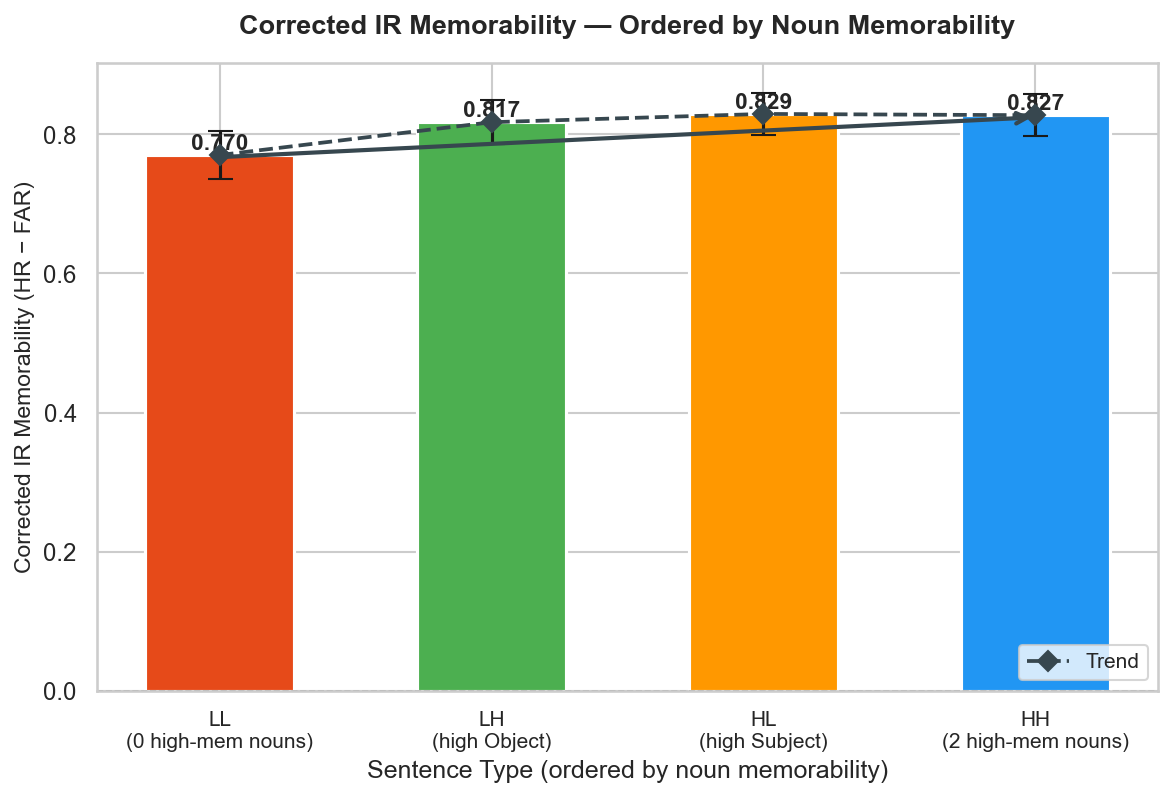


── Corrected IR Memorability by Sentence Type ──
  LL: mean = 0.7702  (n = 112 participants)
  LH: mean = 0.8174  (n = 112 participants)
  HL: mean = 0.8293  (n = 112 participants)
  HH: mean = 0.8275  (n = 112 participants)


In [18]:
# ══════════════════════════════════════════════════════════════════════
# 12c. Corrected IR Memorability (HR_IR − FAR) by Sentence Type
# ══════════════════════════════════════════════════════════════════════

# Participant-level corrected IR
part_ir_corr = (cond_df.groupby(["participant_ID", "sent_type"])["corrected"]
                .mean().reset_index())
ir_corr_agg = (part_ir_corr.groupby("sent_type")["corrected"]
               .agg(["mean", "sem", "count"]).reindex(TYPE_ORDER))

# Order by noun memorability: LL → LH → HL → HH
type_order_mem = ["LL", "LH", "HL", "HH"]
noun_labels = {
    "LL": "LL\n(0 high-mem nouns)",
    "LH": "LH\n(high Object)",
    "HL": "HL\n(high Subject)",
    "HH": "HH\n(2 high-mem nouns)",
}
bar_colors_ir = ["#E64A19", "#4CAF50", "#FF9800", "#2196F3"]

ir_corr_mem = ir_corr_agg.reindex(type_order_mem)

fig, ax = plt.subplots(figsize=(8, 5.5))
x_pos = np.arange(len(type_order_mem))

bars = ax.bar(x_pos, ir_corr_mem["mean"], yerr=ir_corr_mem["sem"] * 1.96, capsize=6,
              color=bar_colors_ir, edgecolor="white", linewidth=1.5, width=0.55)

for bar, t in zip(bars, type_order_mem):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f"{ir_corr_mem.loc[t, 'mean']:.3f}", ha="center", fontsize=11, fontweight="bold")

# Trend line
ax.plot(x_pos, ir_corr_mem["mean"].values, color="#37474F", ls="--", lw=1.8,
        marker="D", markersize=7, zorder=5, label="Trend")

ax.set_xticks(x_pos)
ax.set_xticklabels([noun_labels[t] for t in type_order_mem], fontsize=10)
ax.set_xlabel("Sentence Type (ordered by noun memorability)", fontsize=12)
ax.set_ylabel("Corrected IR Memorability (HR − FAR)", fontsize=11)
ax.set_title("Corrected IR Memorability — Ordered by Noun Memorability",
             fontweight="bold", fontsize=13, pad=14)
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.legend(loc="lower right", fontsize=10)

# Annotation arrow
ax.annotate("", xy=(3, ir_corr_mem.loc["HH", "mean"] - 0.003),
            xytext=(0, ir_corr_mem.loc["LL", "mean"] - 0.003),
            arrowprops=dict(arrowstyle="->", color="#37474F", lw=2))

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "11_corrected_ir_noun_memorability.png"))
plt.show()

print("\n── Corrected IR Memorability by Sentence Type ──")
for t in type_order_mem:
    print(f"  {t}: mean = {ir_corr_mem.loc[t, 'mean']:.4f}  "
          f"(n = {int(ir_corr_mem.loc[t, 'count'])} participants)")

---
## 13. WR Accuracy (Word / Meaning Recognition)

**WR = Word / Meaning Recognition** — measures how often participants correctly identify that a sentence has the **same meaning** but **different wording** (semantic memory).

Example:
- Original: *"The dog chased the cat."*
- Test: *"The cat was chased by the dog."*  → If recognised → WR hit

WR accuracy reflects **semantic-level memory**, whereas IR reflects **surface-level (verbatim) memory**.

> Cognitive research shows: **WR accuracy ≥ IR memorability** — people remember *meaning* better than *exact wording*.

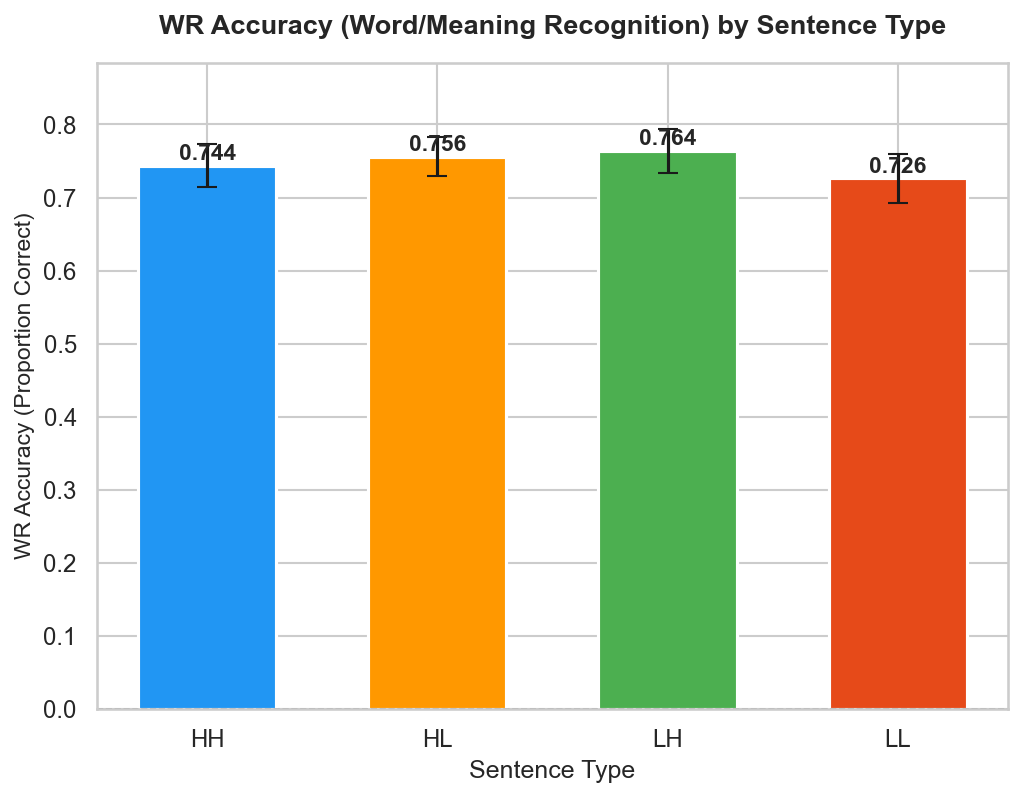


── WR Accuracy by Sentence Type ──
  HH: mean = 0.7438  (±0.0299 95% CI, n = 112)
  HL: mean = 0.7561  (±0.0268 95% CI, n = 112)
  LH: mean = 0.7644  (±0.0301 95% CI, n = 112)
  LL: mean = 0.7261  (±0.0338 95% CI, n = 112)


In [19]:
# ══════════════════════════════════════════════════════════════════════
# 13a. WR Accuracy — Bar Chart by Sentence Type
# ══════════════════════════════════════════════════════════════════════

# Drop NaN WR accuracy rows (non-target / validation items have no ground truth)
cond_wr = cond_df.dropna(subset=["wr_accuracy"]).copy()

# Participant-level WR means per sentence type
part_wr_type = (cond_wr.groupby(["participant_ID", "sent_type"])["wr_accuracy"]
                .mean().reset_index())
wr_type_agg = (part_wr_type.groupby("sent_type")["wr_accuracy"]
               .agg(["mean", "sem", "count"]).reindex(TYPE_ORDER))

fig, ax = plt.subplots(figsize=(7, 5.5))
bars = ax.bar(TYPE_ORDER, wr_type_agg["mean"],
              yerr=wr_type_agg["sem"] * 1.96, capsize=5,
              color=[TYPE_PALETTE[t] for t in TYPE_ORDER],
              edgecolor="white", linewidth=1.5, width=0.6)

for b, t in zip(bars, TYPE_ORDER):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.008,
            f"{wr_type_agg.loc[t, 'mean']:.3f}", ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("WR Accuracy (Proportion Correct)", fontsize=11)
ax.set_xlabel("Sentence Type", fontsize=12)
ax.set_title("WR Accuracy (Word/Meaning Recognition) by Sentence Type",
             fontweight="bold", fontsize=13, pad=14)
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.set_ylim(0, min(1.0, wr_type_agg["mean"].max() + 0.12))

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "12_wr_accuracy_by_type.png"))
plt.show()

print("\n── WR Accuracy by Sentence Type ──")
for t in TYPE_ORDER:
    print(f"  {t}: mean = {wr_type_agg.loc[t, 'mean']:.4f}  "
          f"(±{wr_type_agg.loc[t, 'sem'] * 1.96:.4f} 95% CI, "
          f"n = {int(wr_type_agg.loc[t, 'count'])})")

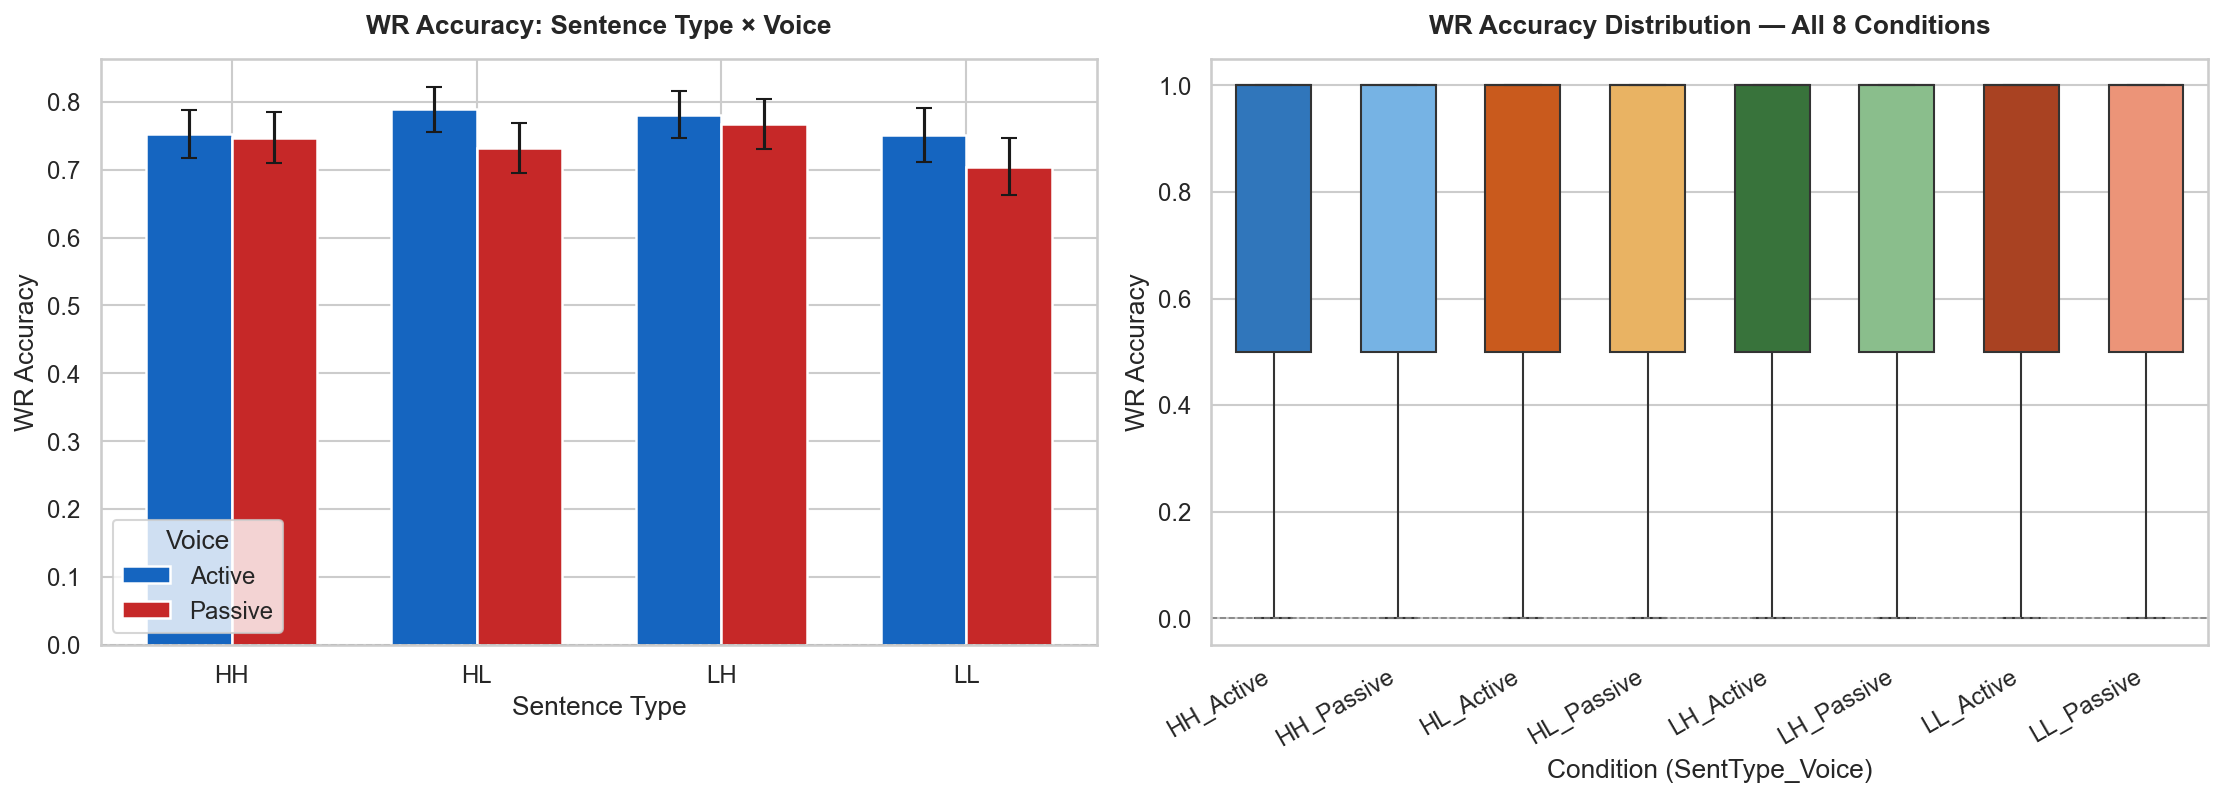

In [20]:
# ══════════════════════════════════════════════════════════════════════
# 13b. WR Accuracy — Grouped Bar: Sentence Type × Voice  +  Boxplots
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── Left: Grouped bar (Type × Voice) ──
ax = axes[0]
x = np.arange(len(TYPE_ORDER))
width = 0.35

for i, v in enumerate(VOICE_ORDER):
    means, cis = [], []
    for t in TYPE_ORDER:
        sub = cond_wr[(cond_wr["sent_type"] == t) & (cond_wr["voice"] == v)]
        m, ci = mean_ci(sub["wr_accuracy"])
        means.append(m); cis.append(ci)
    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width, yerr=cis, capsize=4,
           label=v, color=VOICE_PALETTE[v], edgecolor="white", linewidth=1.2)

ax.set_xticks(x); ax.set_xticklabels(TYPE_ORDER)
ax.set_ylabel("WR Accuracy"); ax.set_xlabel("Sentence Type")
ax.set_title("WR Accuracy: Sentence Type × Voice", fontweight="bold", pad=12)
ax.legend(title="Voice"); ax.axhline(0, color="grey", ls="--", lw=0.8)

# ── Right: Boxplot across all 8 conditions ──
ax = axes[1]
cond_wr["condition_f"] = pd.Categorical(cond_wr["condition"], categories=COND_ORDER, ordered=True)
palette_list = [COND_PALETTE[c] for c in COND_ORDER]
sns.boxplot(data=cond_wr, x="condition_f", y="wr_accuracy",
            palette=palette_list, ax=ax, width=0.6,
            flierprops=dict(marker="o", markersize=3, alpha=0.4))
ax.set_xlabel("Condition (SentType_Voice)")
ax.set_ylabel("WR Accuracy")
ax.set_title("WR Accuracy Distribution — All 8 Conditions", fontweight="bold", pad=12)
ax.axhline(0, color="grey", ls="--", lw=0.8)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "13_wr_type_x_voice.png"))
plt.show()

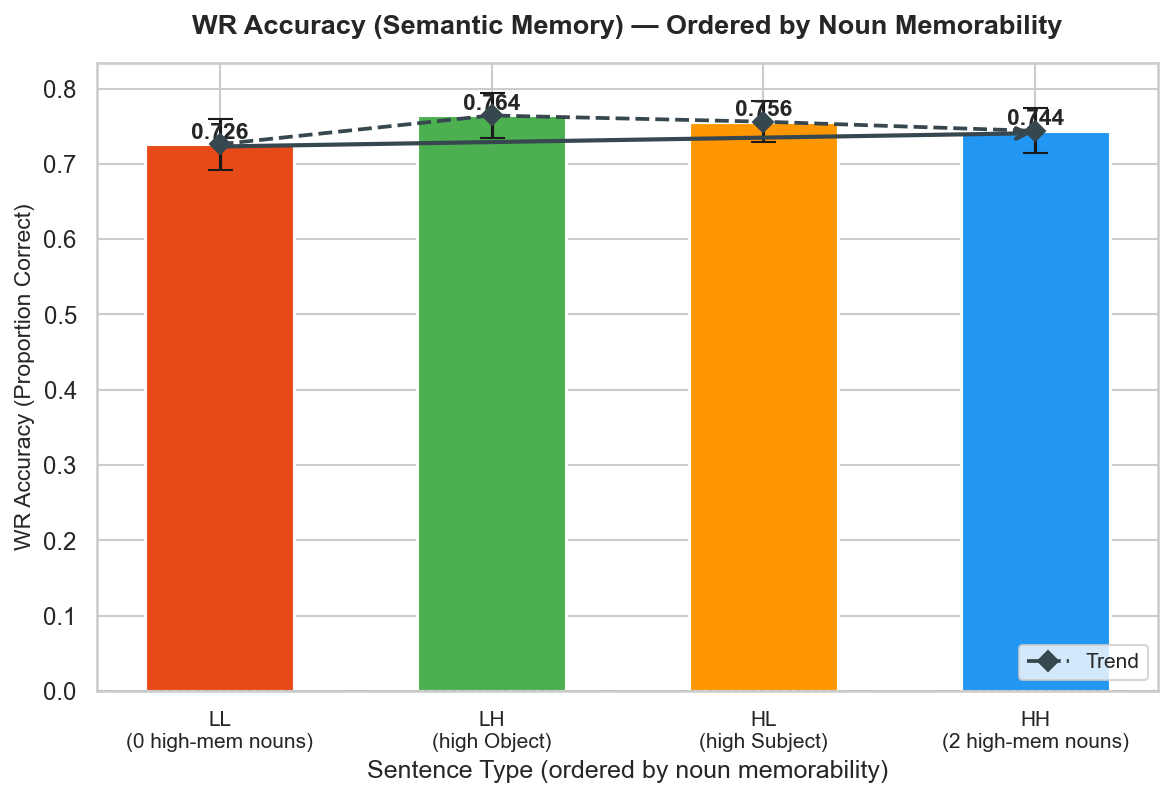


── WR Accuracy by Noun Memorability ──
  LL: mean = 0.7261  (n = 112 participants)
  LH: mean = 0.7644  (n = 112 participants)
  HL: mean = 0.7561  (n = 112 participants)
  HH: mean = 0.7438  (n = 112 participants)


In [21]:
# ══════════════════════════════════════════════════════════════════════
# 13c. WR Accuracy — Ordered by Noun Memorability
# ══════════════════════════════════════════════════════════════════════

type_order_mem = ["LL", "LH", "HL", "HH"]
noun_labels = {
    "LL": "LL\n(0 high-mem nouns)",
    "LH": "LH\n(high Object)",
    "HL": "HL\n(high Subject)",
    "HH": "HH\n(2 high-mem nouns)",
}
bar_colors_wr = ["#E64A19", "#4CAF50", "#FF9800", "#2196F3"]

wr_mem_agg = (part_wr_type.groupby("sent_type")["wr_accuracy"]
              .agg(["mean", "sem", "count"]).reindex(type_order_mem))

fig, ax = plt.subplots(figsize=(8, 5.5))
x_pos = np.arange(len(type_order_mem))

bars = ax.bar(x_pos, wr_mem_agg["mean"], yerr=wr_mem_agg["sem"] * 1.96, capsize=6,
              color=bar_colors_wr, edgecolor="white", linewidth=1.5, width=0.55)

for bar, t in zip(bars, type_order_mem):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f"{wr_mem_agg.loc[t, 'mean']:.3f}", ha="center", fontsize=11, fontweight="bold")

# Trend line
ax.plot(x_pos, wr_mem_agg["mean"].values, color="#37474F", ls="--", lw=1.8,
        marker="D", markersize=7, zorder=5, label="Trend")

ax.set_xticks(x_pos)
ax.set_xticklabels([noun_labels[t] for t in type_order_mem], fontsize=10)
ax.set_xlabel("Sentence Type (ordered by noun memorability)", fontsize=12)
ax.set_ylabel("WR Accuracy (Proportion Correct)", fontsize=11)
ax.set_title("WR Accuracy (Semantic Memory) — Ordered by Noun Memorability",
             fontweight="bold", fontsize=13, pad=14)
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.legend(loc="lower right", fontsize=10)

ax.annotate("", xy=(3, wr_mem_agg.loc["HH", "mean"] - 0.003),
            xytext=(0, wr_mem_agg.loc["LL", "mean"] - 0.003),
            arrowprops=dict(arrowstyle="->", color="#37474F", lw=2))

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "14_wr_accuracy_noun_memorability.png"))
plt.show()

print("\n── WR Accuracy by Noun Memorability ──")
for t in type_order_mem:
    print(f"  {t}: mean = {wr_mem_agg.loc[t, 'mean']:.4f}  "
          f"(n = {int(wr_mem_agg.loc[t, 'count'])} participants)")

---
## 14. IR vs WR Comparison — Surface Memory vs Semantic Memory

Side-by-side comparison of **IR Memorability** (verbatim/surface memory) and **WR Accuracy** (semantic/meaning memory).

> Cognitive research predicts: **WR ≥ IR** — people retain *meaning* better than *exact wording*.

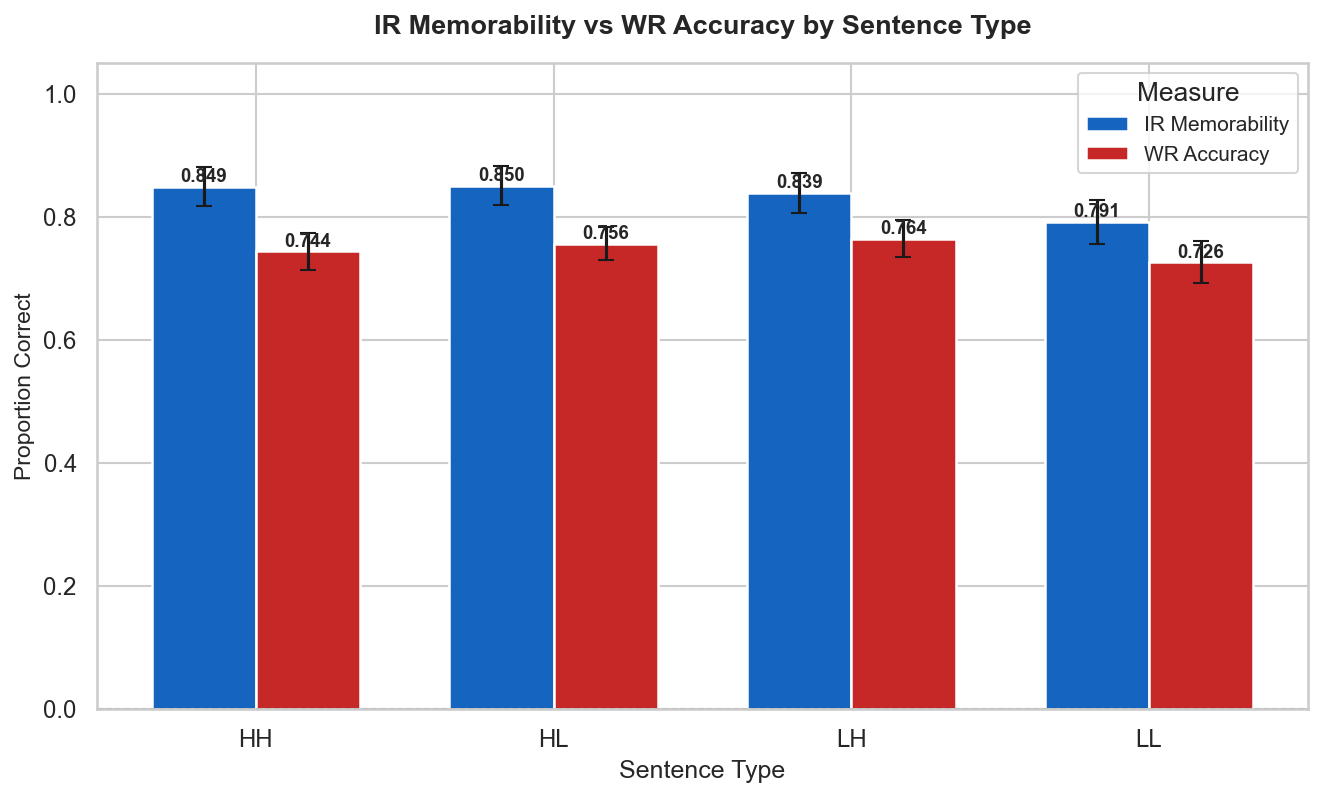


── IR vs WR Comparison ──
  HH:  IR = 0.8486   WR = 0.7438   Δ(WR−IR) = -0.1048
  HL:  IR = 0.8504   WR = 0.7561   Δ(WR−IR) = -0.0943
  LH:  IR = 0.8385   WR = 0.7644   Δ(WR−IR) = -0.0742
  LL:  IR = 0.7913   WR = 0.7261   Δ(WR−IR) = -0.0652


In [22]:
# ══════════════════════════════════════════════════════════════════════
# 14a. IR vs WR — Grouped Comparison by Sentence Type
# ══════════════════════════════════════════════════════════════════════

# Build a long-form dataframe with both IR and WR per participant × type
ir_long = (cond_df.groupby(["participant_ID", "sent_type"])["hit_rate"]
           .mean().reset_index().rename(columns={"hit_rate": "score"}))
ir_long["measure"] = "IR Memorability"

wr_long = (cond_wr.groupby(["participant_ID", "sent_type"])["wr_accuracy"]
           .mean().reset_index().rename(columns={"wr_accuracy": "score"}))
wr_long["measure"] = "WR Accuracy"

compare_df = pd.concat([ir_long, wr_long], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(TYPE_ORDER))
width = 0.35
measure_colors = {"IR Memorability": "#1565C0", "WR Accuracy": "#C62828"}

for i, meas in enumerate(["IR Memorability", "WR Accuracy"]):
    means, cis = [], []
    for t in TYPE_ORDER:
        sub = compare_df[(compare_df["sent_type"] == t) & (compare_df["measure"] == meas)]
        m, ci = mean_ci(sub["score"])
        means.append(m); cis.append(ci)
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, means, width, yerr=cis, capsize=4,
                  label=meas, color=measure_colors[meas],
                  edgecolor="white", linewidth=1.2)
    # Value labels
    for b, m_val in zip(bars, means):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.008,
                f"{m_val:.3f}", ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(TYPE_ORDER)
ax.set_ylabel("Proportion Correct", fontsize=11)
ax.set_xlabel("Sentence Type", fontsize=12)
ax.set_title("IR Memorability vs WR Accuracy by Sentence Type",
             fontweight="bold", fontsize=13, pad=14)
ax.legend(title="Measure", fontsize=10)
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.set_ylim(0, 1.05)

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "15_ir_vs_wr_by_type.png"))
plt.show()

# Print difference summary
print("\n── IR vs WR Comparison ──")
for t in TYPE_ORDER:
    ir_m = compare_df[(compare_df["sent_type"] == t) & (compare_df["measure"] == "IR Memorability")]["score"].mean()
    wr_m = compare_df[(compare_df["sent_type"] == t) & (compare_df["measure"] == "WR Accuracy")]["score"].mean()
    diff = wr_m - ir_m
    print(f"  {t}:  IR = {ir_m:.4f}   WR = {wr_m:.4f}   Δ(WR−IR) = {diff:+.4f}")

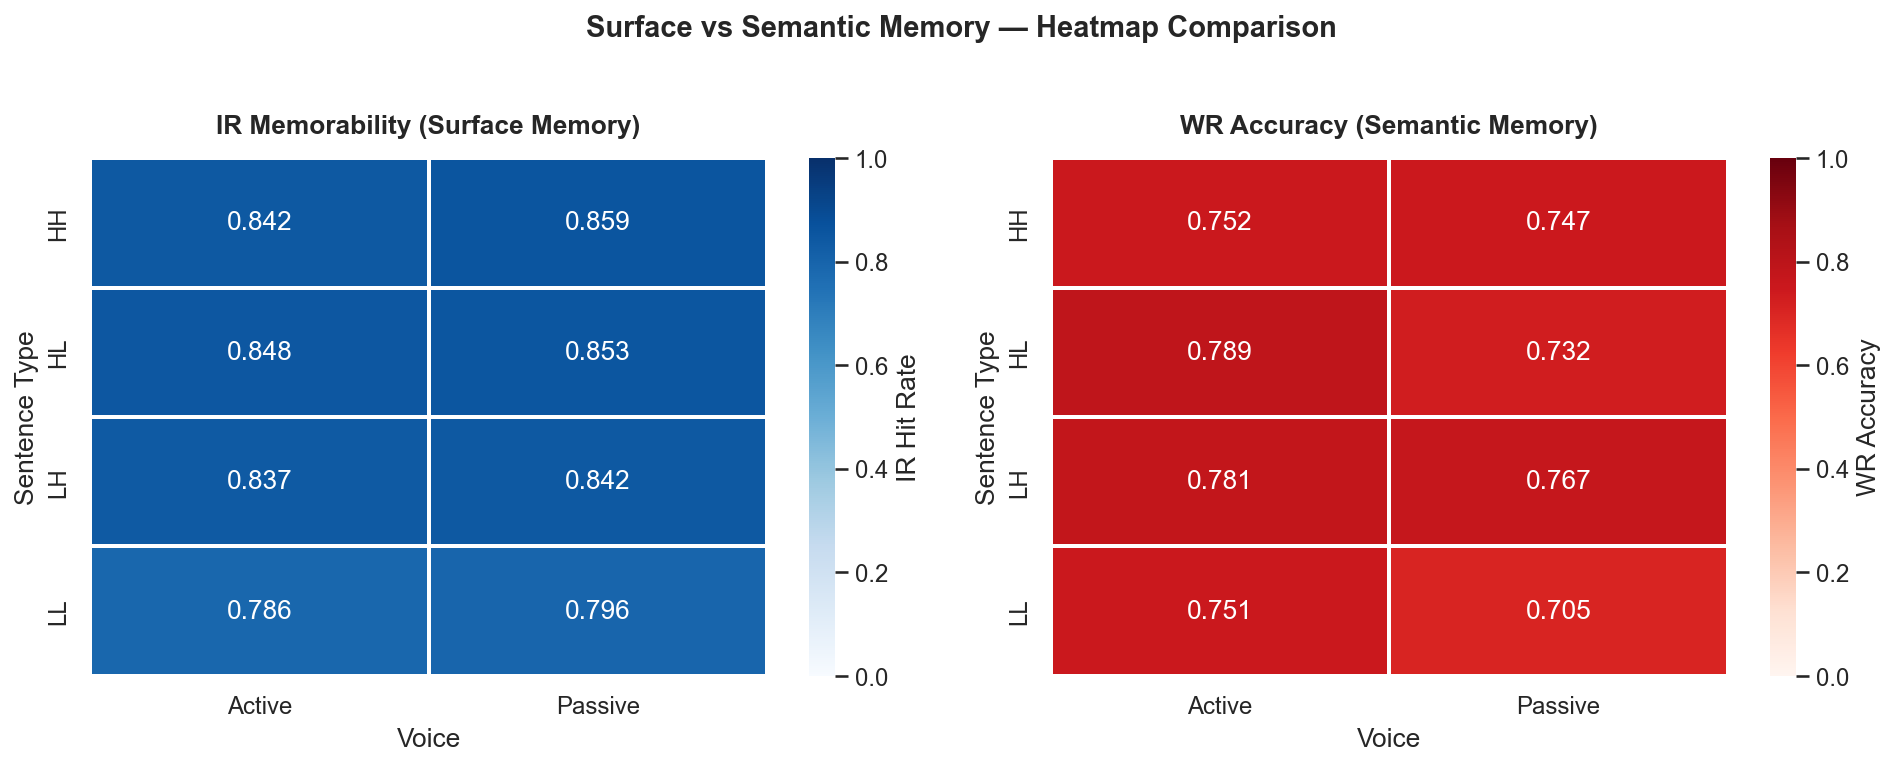

In [23]:
# ══════════════════════════════════════════════════════════════════════
# 14b. IR vs WR — Heatmaps Side-by-Side (Type × Voice)
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# IR heatmap
heat_ir = (cond_df.groupby(["sent_type", "voice"])["hit_rate"]
           .mean().unstack("voice")
           .reindex(index=TYPE_ORDER, columns=VOICE_ORDER))
sns.heatmap(heat_ir, annot=True, fmt=".3f", cmap="Blues",
            linewidths=1, ax=axes[0], vmin=0, vmax=1,
            cbar_kws={"label": "IR Hit Rate"})
axes[0].set_title("IR Memorability (Surface Memory)", fontweight="bold", pad=12)
axes[0].set_ylabel("Sentence Type"); axes[0].set_xlabel("Voice")

# WR heatmap
heat_wr = (cond_wr.groupby(["sent_type", "voice"])["wr_accuracy"]
           .mean().unstack("voice")
           .reindex(index=TYPE_ORDER, columns=VOICE_ORDER))
sns.heatmap(heat_wr, annot=True, fmt=".3f", cmap="Reds",
            linewidths=1, ax=axes[1], vmin=0, vmax=1,
            cbar_kws={"label": "WR Accuracy"})
axes[1].set_title("WR Accuracy (Semantic Memory)", fontweight="bold", pad=12)
axes[1].set_ylabel("Sentence Type"); axes[1].set_xlabel("Voice")

fig.suptitle("Surface vs Semantic Memory — Heatmap Comparison",
             fontweight="bold", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "16_ir_wr_heatmaps.png"), bbox_inches="tight")
plt.show()

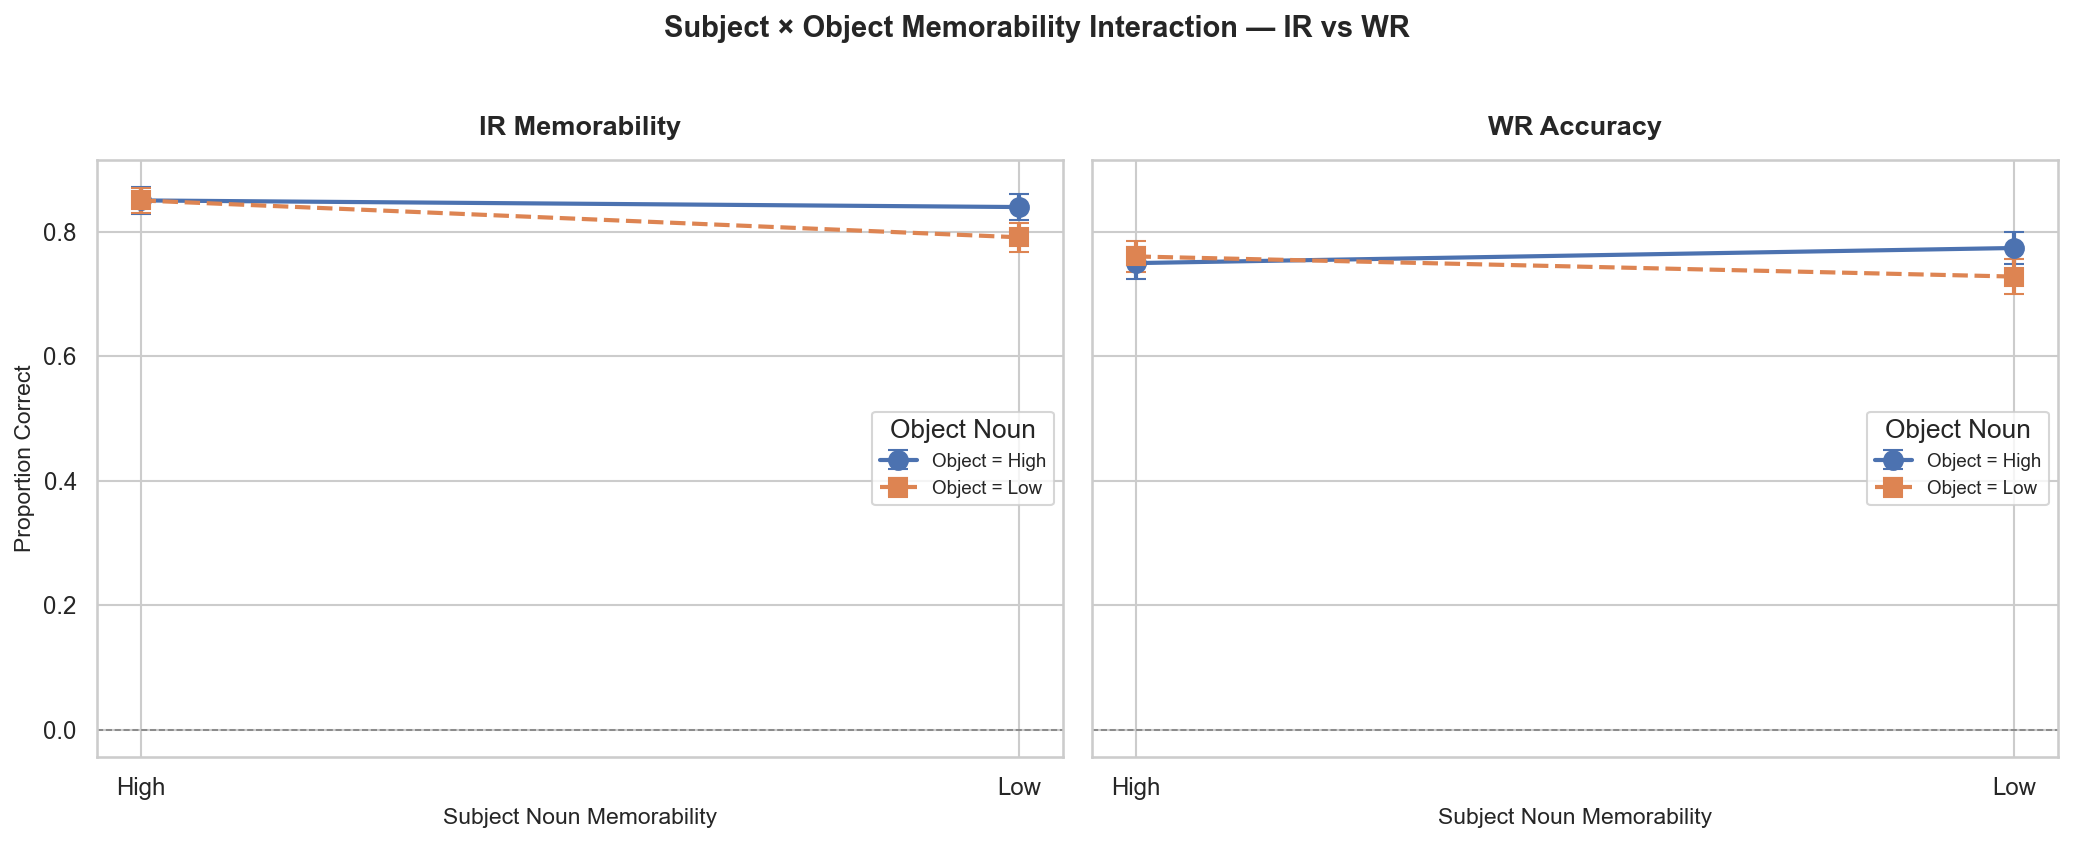

In [24]:
# ══════════════════════════════════════════════════════════════════════
# 14c. IR vs WR — Interaction Plot (Subject × Object Memorability)
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
measure_map = {"IR Memorability": ("hit_rate", cond_df),
               "WR Accuracy": ("wr_accuracy", cond_wr)}

for idx, (title, (col, src_df)) in enumerate(measure_map.items()):
    ax = axes[idx]
    int_data = (src_df.groupby(["subject_mem", "object_mem"])[col]
                .agg(["mean", "sem"]).reset_index())

    for obj_level, marker, ls in [("High", "o", "-"), ("Low", "s", "--")]:
        sub = int_data[int_data["object_mem"] == obj_level].sort_values("subject_mem")
        ax.errorbar(sub["subject_mem"], sub["mean"], yerr=sub["sem"] * 1.96,
                    marker=marker, ls=ls, lw=2, markersize=9, capsize=5,
                    label=f"Object = {obj_level}")

    ax.set_xlabel("Subject Noun Memorability", fontsize=11)
    ax.set_ylabel("Proportion Correct" if idx == 0 else "", fontsize=11)
    ax.set_title(title, fontweight="bold", fontsize=13, pad=12)
    ax.legend(title="Object Noun", fontsize=9)
    ax.axhline(0, color="grey", ls="--", lw=0.8)

fig.suptitle("Subject × Object Memorability Interaction — IR vs WR",
             fontweight="bold", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "17_ir_wr_interaction.png"), bbox_inches="tight")
plt.show()

In [25]:
# ══════════════════════════════════════════════════════════════════════
# 14d. Descriptive Statistics — IR Memorability & WR Accuracy
# ══════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  DESCRIPTIVE STATISTICS — IR vs WR by Sentence Type")
print("=" * 65)

# IR stats
ir_desc = (cond_df.groupby("sent_type")["hit_rate"]
           .agg(["mean", "std"]).reindex(TYPE_ORDER)
           .rename(columns={"mean": "IR Mean", "std": "IR Std"}))

# WR stats
wr_desc = (cond_wr.groupby("sent_type")["wr_accuracy"]
           .agg(["mean", "std"]).reindex(TYPE_ORDER)
           .rename(columns={"mean": "WR Mean", "std": "WR Std"}))

desc_combined = pd.concat([ir_desc, wr_desc], axis=1)
desc_combined["Δ (WR − IR)"] = desc_combined["WR Mean"] - desc_combined["IR Mean"]
desc_combined.index.name = "Type"

print(desc_combined.to_string(float_format=lambda x: f"{x:.4f}"))

# Overall means
overall_ir = cond_df["hit_rate"].mean()
overall_wr = cond_wr["wr_accuracy"].mean()
print(f"\n── Overall ──")
print(f"  Mean IR Memorability : {overall_ir:.4f}")
print(f"  Mean WR Accuracy     : {overall_wr:.4f}")
print(f"  Δ (WR − IR)          : {overall_wr - overall_ir:+.4f}")
if overall_wr >= overall_ir:
    print(f"\n  ✅ WR ≥ IR — consistent with semantic > surface memory hypothesis")
else:
    print(f"\n  ⚠️ WR < IR — unexpected; warrants further investigation")

# ── LaTeX table ──
latex_rows = []
for t in TYPE_ORDER:
    ir_m = desc_combined.loc[t, "IR Mean"]
    ir_s = desc_combined.loc[t, "IR Std"]
    wr_m = desc_combined.loc[t, "WR Mean"]
    wr_s = desc_combined.loc[t, "WR Std"]
    d = desc_combined.loc[t, "Δ (WR − IR)"]
    latex_rows.append(f"    {t} & {ir_m:.4f} & {ir_s:.4f} & {wr_m:.4f} & {wr_s:.4f} & {d:+.4f} \\\\")

latex_table = r"""\begin{table}[h]
\centering
\begin{tabular}{cccccc}
\toprule
Type & IR Mean & IR SD & WR Mean & WR SD & $\Delta$ (WR $-$ IR) \\
\midrule
""" + "\n".join(latex_rows) + r"""
\bottomrule
\end{tabular}
\caption{IR memorability and WR accuracy by sentence type}
\label{tab:ir_wr}
\end{table}"""

print("\n\n── LaTeX (copy-paste ready) ──\n")
print(latex_table)

  DESCRIPTIVE STATISTICS — IR vs WR by Sentence Type
      IR Mean  IR Std  WR Mean  WR Std  Δ (WR − IR)
Type                                               
HH     0.8503  0.2786   0.7496  0.3290      -0.1007
HL     0.8503  0.2689   0.7603  0.3183      -0.0900
LH     0.8397  0.2782   0.7739  0.3217      -0.0658
LL     0.7910  0.3097   0.7279  0.3629      -0.0631

── Overall ──
  Mean IR Memorability : 0.8328
  Mean WR Accuracy     : 0.7531
  Δ (WR − IR)          : -0.0797

  ⚠️ WR < IR — unexpected; warrants further investigation


── LaTeX (copy-paste ready) ──

\begin{table}[h]
\centering
\begin{tabular}{cccccc}
\toprule
Type & IR Mean & IR SD & WR Mean & WR SD & $\Delta$ (WR $-$ IR) \\
\midrule
    HH & 0.8503 & 0.2786 & 0.7496 & 0.3290 & -0.1007 \\
    HL & 0.8503 & 0.2689 & 0.7603 & 0.3183 & -0.0900 \\
    LH & 0.8397 & 0.2782 & 0.7739 & 0.3217 & -0.0658 \\
    LL & 0.7910 & 0.3097 & 0.7279 & 0.3629 & -0.0631 \\
\bottomrule
\end{tabular}
\caption{IR memorability and WR accuracy by

---
## 15. Score Distributions — IR Memorability & WR Accuracy

### IR Memorability Score
Distribution of **IR hit rates** (proportion of identical repetitions correctly recognised) across all participant × condition observations.

### WR Accuracy Score (conditional on correct IR)
WR accuracy is computed **only for trials where the participant correctly recognised the sentence via IR** (Accuracy IR = 1).  
This isolates *semantic memory*: given that the participant detected the exact repetition, how well do they judge word-level / meaning-level recognition?

In [30]:
# ══════════════════════════════════════════════════════════════════════
# 15a. Recompute WR Accuracy — ONLY for trials with correct IR
# ══════════════════════════════════════════════════════════════════════

wr_given_ir_rows = []
for (pid, blk), g in df_valid.groupby(["participant_ID", "block"]):
    far = pb_df.loc[(pb_df["participant_ID"] == pid) &
                    (pb_df["block"] == blk), "fa_rate"].iloc[0]

    for st in TYPE_ORDER:
        for v in VOICE_ORDER:
            # Stimuli with correct IR press
            correct_ir = g[(g["Event"] == "IR pressed") &
                           (g["isTarget"]) & (g["isRepeat"]) &
                           (g["sent_type"] == st) & (g["voice"] == v) &
                           (g["Accuracy IR"] == 1)]
            correct_ir_stims = set(correct_ir["Stimulus"].values)

            if not correct_ir_stims:
                continue

            # WR events for those same stimuli only
            wr_correct = g[(g["Event"] == "WR pressed") &
                           (g["isTarget"]) & (g["isRepeat"]) &
                           (g["sent_type"] == st) & (g["voice"] == v) &
                           (g["Stimulus"].isin(correct_ir_stims))]

            wr_acc_vals = wr_correct["Accuracy WR"].dropna()
            if len(wr_acc_vals) == 0:
                continue

            wr_acc = wr_acc_vals.mean()
            wr_given_ir_rows.append(dict(
                participant_ID=pid, block=blk,
                sent_type=st, voice=v, condition=f"{st}_{v}",
                wr_accuracy_given_ir=wr_acc,
                n_correct_ir=len(correct_ir_stims),
                n_wr_responses=len(wr_acc_vals)))

wr_ir_df = pd.DataFrame(wr_given_ir_rows)

# Add subject / object labels
wr_ir_df["subject_mem"] = wr_ir_df["sent_type"].map(lambda t: subj_obj.get(t, (None, None))[0])
wr_ir_df["object_mem"]  = wr_ir_df["sent_type"].map(lambda t: subj_obj.get(t, (None, None))[1])

print(f"WR|correct-IR observations : {len(wr_ir_df)}")
print(f"Mean WR accuracy (given correct IR): {wr_ir_df['wr_accuracy_given_ir'].mean():.4f}")
print(f"Mean IR hit rate (from cond_df)    : {cond_df['hit_rate'].mean():.4f}")

WR|correct-IR observations : 2497
Mean WR accuracy (given correct IR): 0.7531
Mean IR hit rate (from cond_df)    : 0.8328


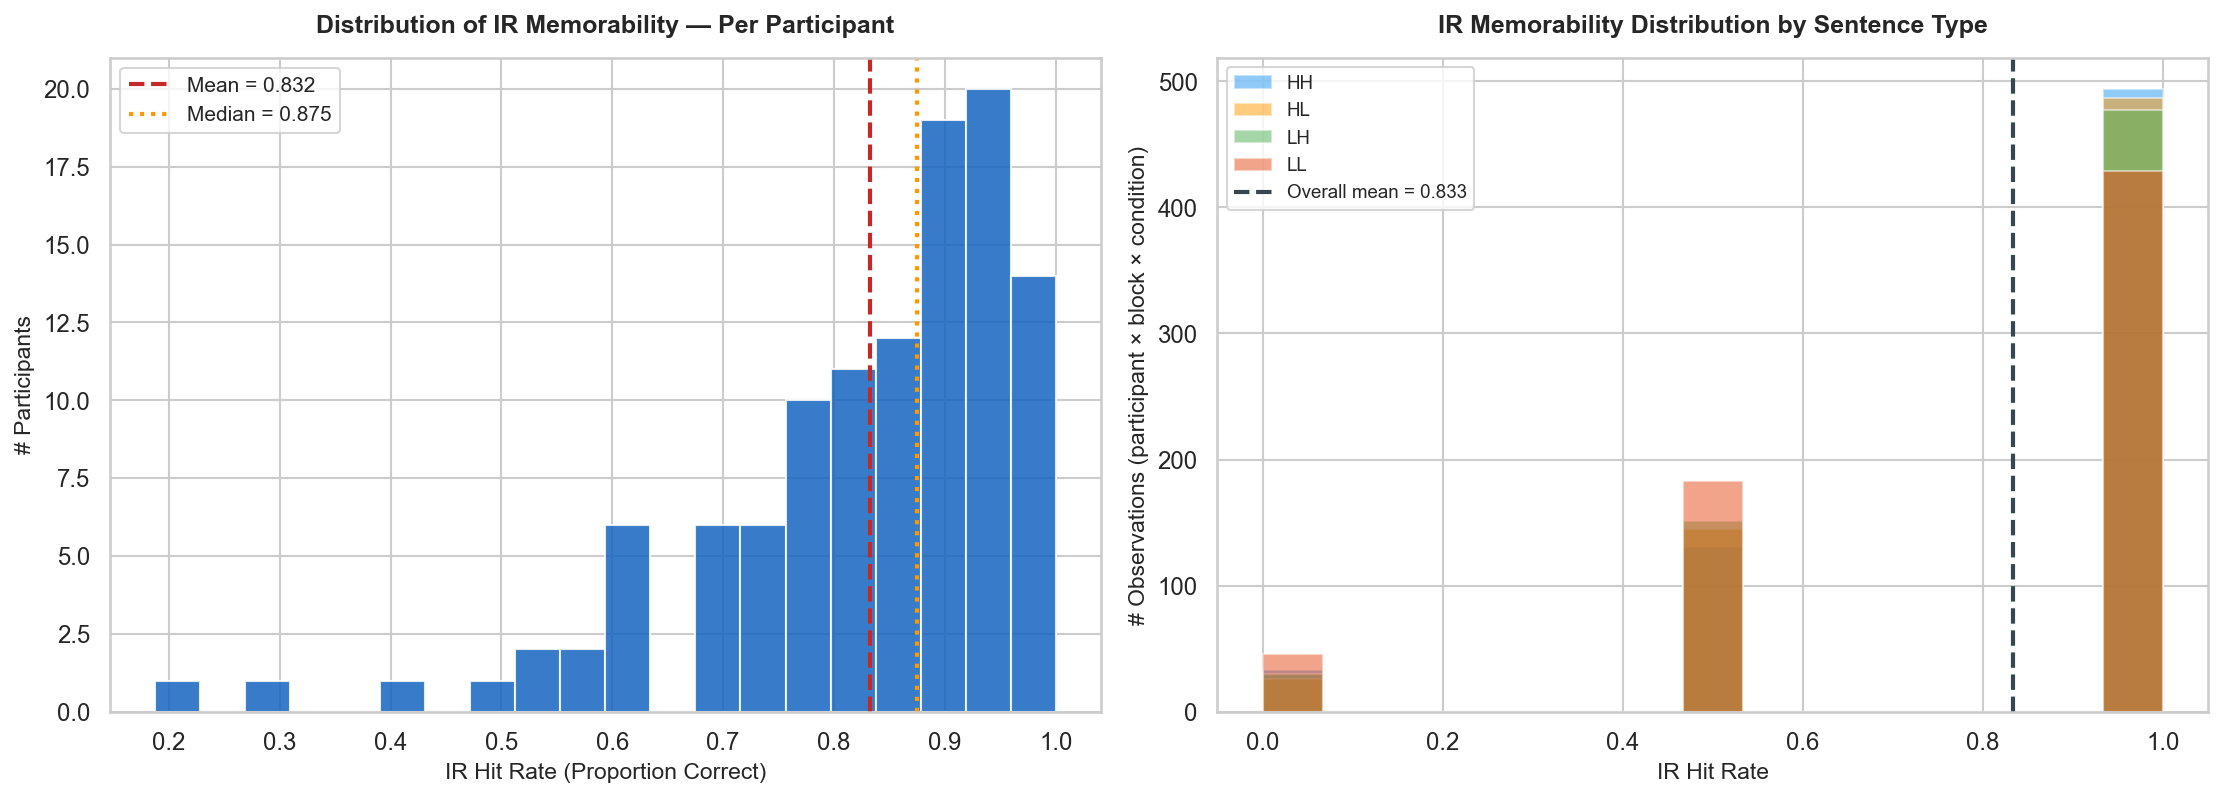


── IR Memorability Distribution Summary ──
  N participants      : 112
  Mean                : 0.8322
  Median              : 0.8750
  Std Dev             : 0.1508
  Range               : [0.1875, 1.0000]
  IQR                 : [0.7708, 0.9375]


In [31]:
# ══════════════════════════════════════════════════════════════════════
# 15b. Distribution of IR Memorability Scores
# ══════════════════════════════════════════════════════════════════════

# Participant-level IR scores (mean hit_rate per participant)
part_ir = cond_df.groupby("participant_ID")["hit_rate"].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── Left: Overall IR distribution (participant-level) ──
ax = axes[0]
ax.hist(part_ir, bins=20, color="#1565C0", edgecolor="white", alpha=0.85)
ax.axvline(part_ir.mean(), color="#C62828", ls="--", lw=2,
           label=f"Mean = {part_ir.mean():.3f}")
ax.axvline(part_ir.median(), color="#FF9800", ls=":", lw=2,
           label=f"Median = {part_ir.median():.3f}")
ax.set_xlabel("IR Hit Rate (Proportion Correct)", fontsize=11)
ax.set_ylabel("# Participants", fontsize=11)
ax.set_title("Distribution of IR Memorability — Per Participant",
             fontweight="bold", fontsize=12, pad=12)
ax.legend(fontsize=10)

# ── Right: IR distribution by sentence type (condition-level) ──
ax = axes[1]
for t in TYPE_ORDER:
    sub = cond_df[cond_df["sent_type"] == t]["hit_rate"]
    ax.hist(sub, bins=15, alpha=0.5, color=TYPE_PALETTE[t], label=t, edgecolor="white")
ax.axvline(cond_df["hit_rate"].mean(), color="#37474F", ls="--", lw=2,
           label=f"Overall mean = {cond_df['hit_rate'].mean():.3f}")
ax.set_xlabel("IR Hit Rate", fontsize=11)
ax.set_ylabel("# Observations (participant × block × condition)", fontsize=11)
ax.set_title("IR Memorability Distribution by Sentence Type",
             fontweight="bold", fontsize=12, pad=12)
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "18_ir_score_distribution.png"))
plt.show()

# ── Summary stats ──
print("\n── IR Memorability Distribution Summary ──")
print(f"  N participants      : {len(part_ir)}")
print(f"  Mean                : {part_ir.mean():.4f}")
print(f"  Median              : {part_ir.median():.4f}")
print(f"  Std Dev             : {part_ir.std():.4f}")
print(f"  Range               : [{part_ir.min():.4f}, {part_ir.max():.4f}]")
print(f"  IQR                 : [{part_ir.quantile(0.25):.4f}, {part_ir.quantile(0.75):.4f}]")

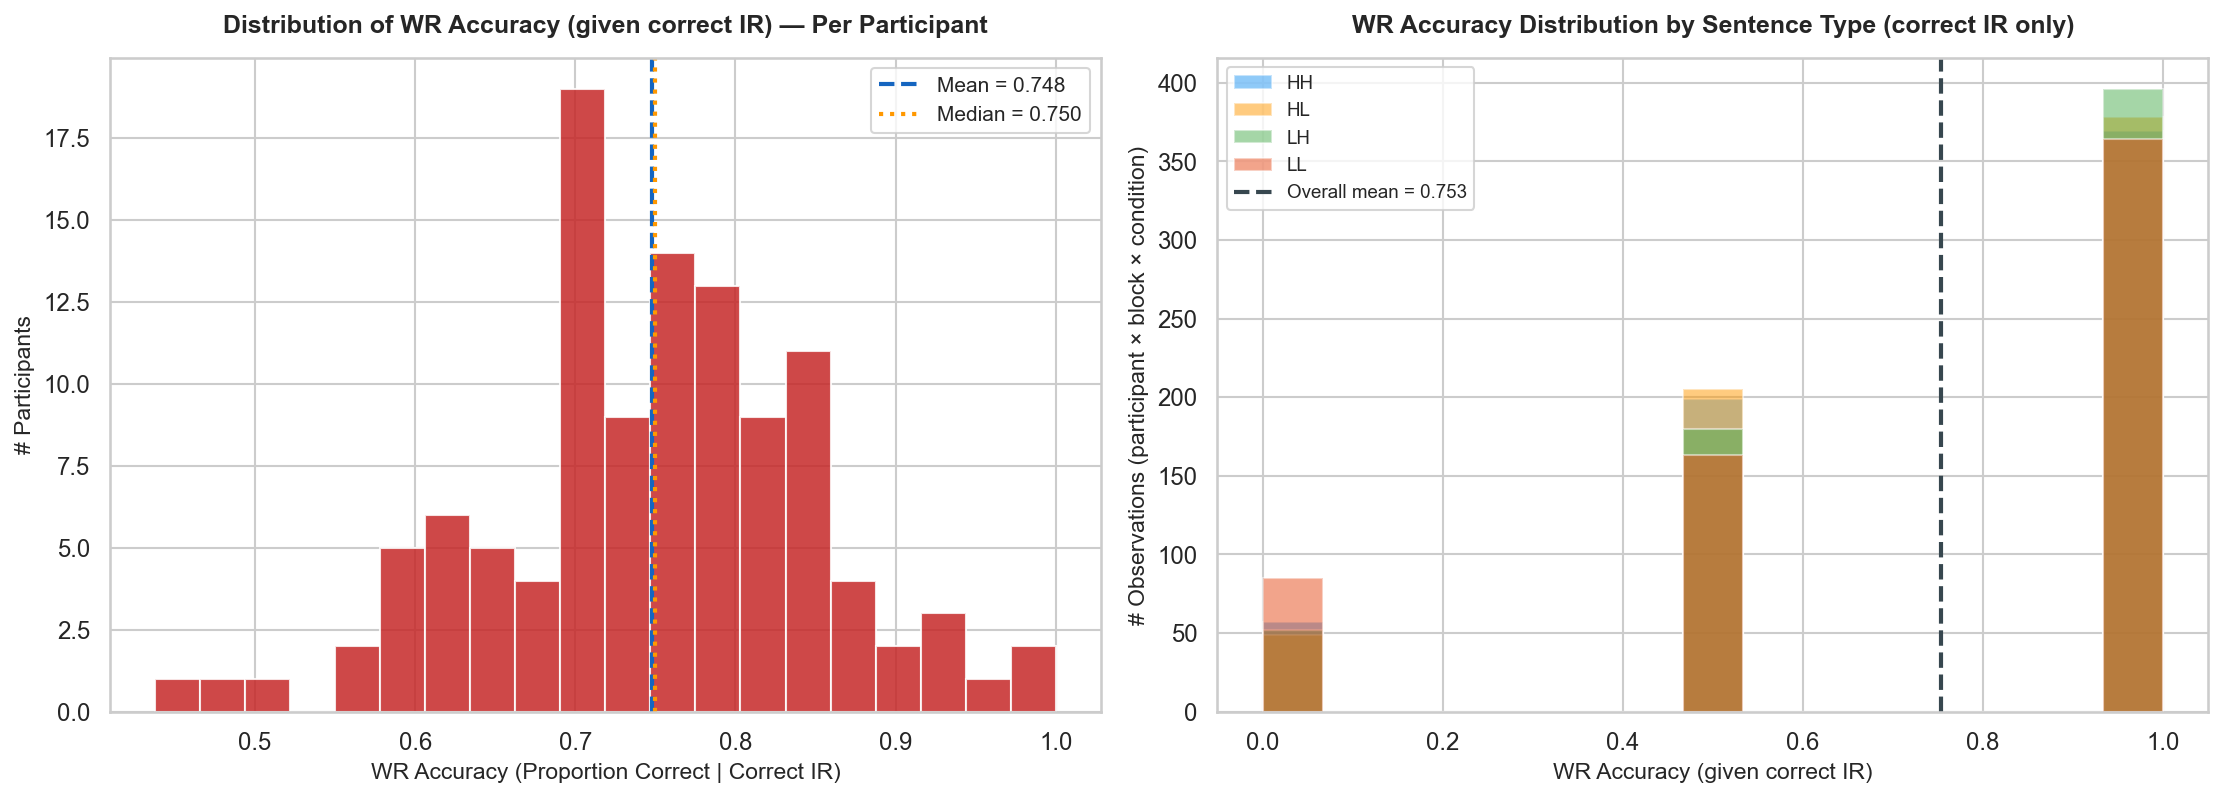


── WR Accuracy (given correct IR) Distribution Summary ──
  N participants      : 112
  Mean                : 0.7477
  Median              : 0.7500
  Std Dev             : 0.1025
  Range               : [0.4375, 1.0000]
  IQR                 : [0.6957, 0.8125]


In [32]:
# ══════════════════════════════════════════════════════════════════════
# 15c. Distribution of WR Accuracy Scores (conditional on correct IR)
# ══════════════════════════════════════════════════════════════════════

# Participant-level WR|correct-IR scores
part_wr_ir = wr_ir_df.groupby("participant_ID")["wr_accuracy_given_ir"].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── Left: Overall WR|IR distribution (participant-level) ──
ax = axes[0]
ax.hist(part_wr_ir, bins=20, color="#C62828", edgecolor="white", alpha=0.85)
ax.axvline(part_wr_ir.mean(), color="#1565C0", ls="--", lw=2,
           label=f"Mean = {part_wr_ir.mean():.3f}")
ax.axvline(part_wr_ir.median(), color="#FF9800", ls=":", lw=2,
           label=f"Median = {part_wr_ir.median():.3f}")
ax.set_xlabel("WR Accuracy (Proportion Correct | Correct IR)", fontsize=11)
ax.set_ylabel("# Participants", fontsize=11)
ax.set_title("Distribution of WR Accuracy (given correct IR) — Per Participant",
             fontweight="bold", fontsize=12, pad=12)
ax.legend(fontsize=10)

# ── Right: WR|IR distribution by sentence type (condition-level) ──
ax = axes[1]
for t in TYPE_ORDER:
    sub = wr_ir_df[wr_ir_df["sent_type"] == t]["wr_accuracy_given_ir"]
    ax.hist(sub, bins=15, alpha=0.5, color=TYPE_PALETTE[t], label=t, edgecolor="white")
ax.axvline(wr_ir_df["wr_accuracy_given_ir"].mean(), color="#37474F", ls="--", lw=2,
           label=f"Overall mean = {wr_ir_df['wr_accuracy_given_ir'].mean():.3f}")
ax.set_xlabel("WR Accuracy (given correct IR)", fontsize=11)
ax.set_ylabel("# Observations (participant × block × condition)", fontsize=11)
ax.set_title("WR Accuracy Distribution by Sentence Type (correct IR only)",
             fontweight="bold", fontsize=12, pad=12)
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "19_wr_score_distribution.png"))
plt.show()

# ── Summary stats ──
print("\n── WR Accuracy (given correct IR) Distribution Summary ──")
print(f"  N participants      : {len(part_wr_ir)}")
print(f"  Mean                : {part_wr_ir.mean():.4f}")
print(f"  Median              : {part_wr_ir.median():.4f}")
print(f"  Std Dev             : {part_wr_ir.std():.4f}")
print(f"  Range               : [{part_wr_ir.min():.4f}, {part_wr_ir.max():.4f}]")
print(f"  IQR                 : [{part_wr_ir.quantile(0.25):.4f}, {part_wr_ir.quantile(0.75):.4f}]")

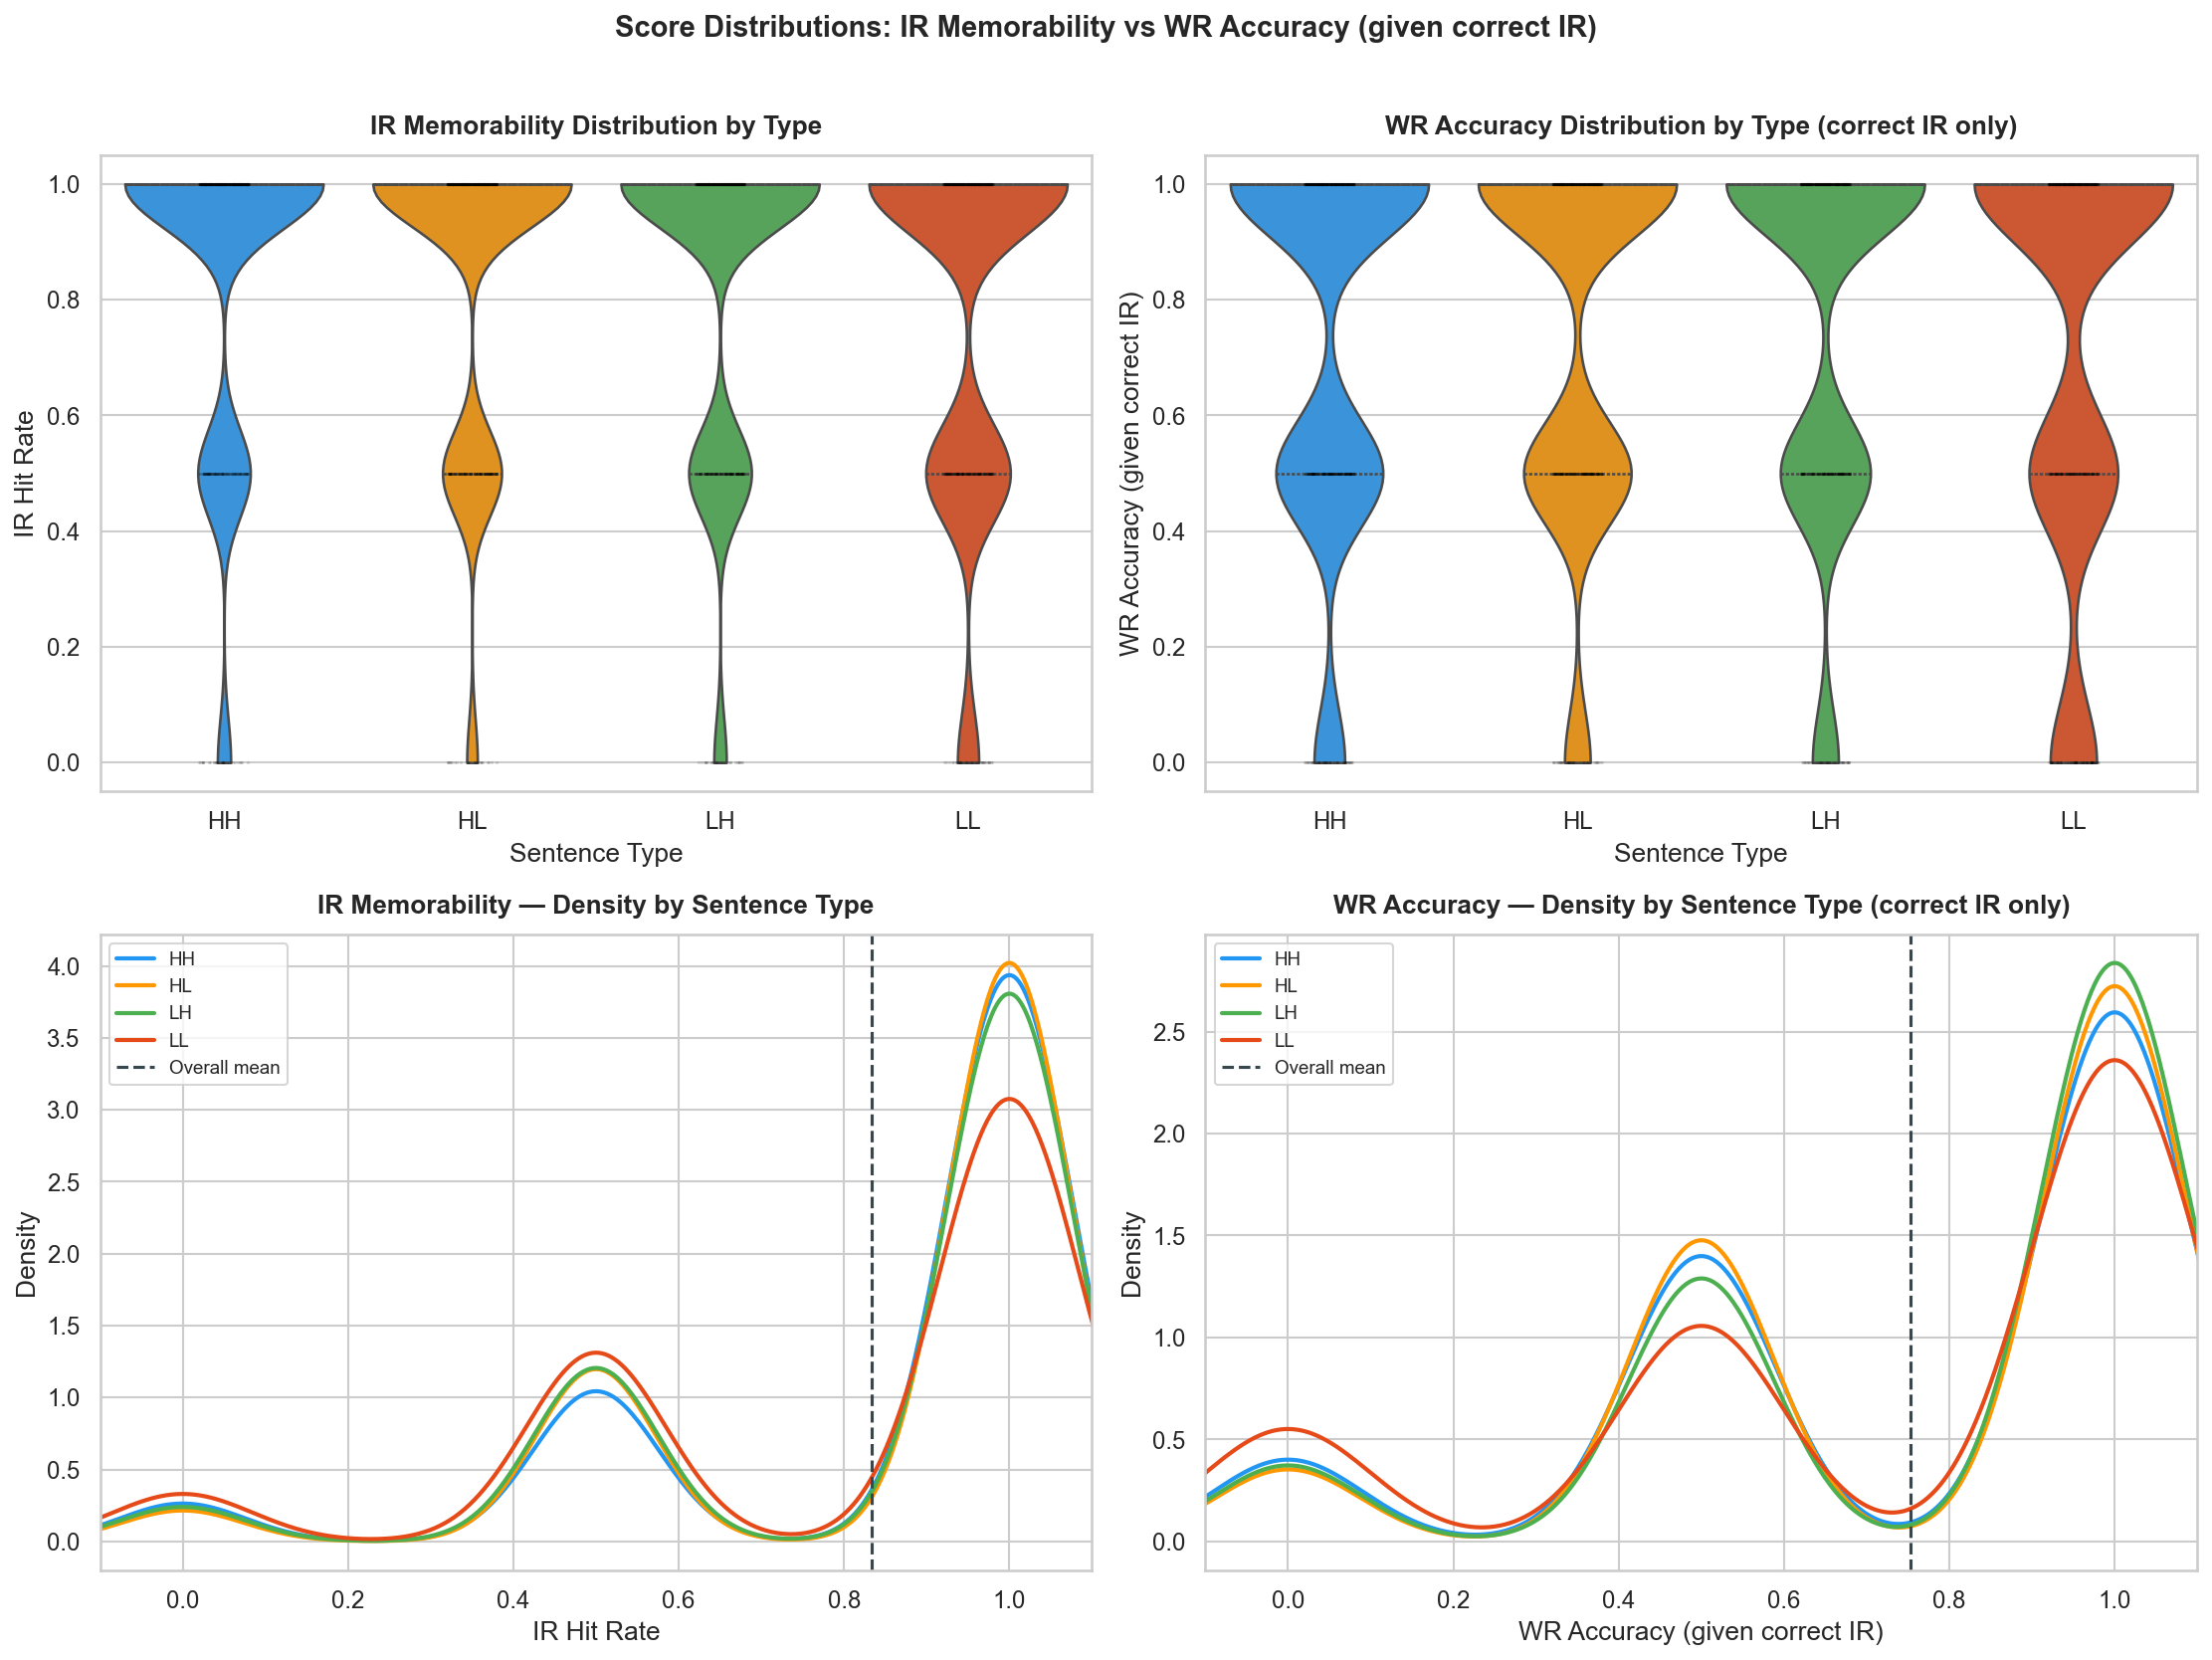


── IR vs WR (given correct IR) — By Sentence Type ──
Type      IR Mean     IR Std   WR|IR Mean    WR|IR Std   Δ(WR−IR)
──────────────────────────────────────────────────────────────
  HH       0.8503     0.2786       0.7496       0.3290    -0.1007
  HL       0.8503     0.2689       0.7603       0.3183    -0.0900
  LH       0.8397     0.2782       0.7739       0.3217    -0.0658
  LL       0.7910     0.3097       0.7279       0.3629    -0.0631


In [33]:
# ══════════════════════════════════════════════════════════════════════
# 15d. Side-by-Side Comparison: IR vs WR Score Distributions
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# ── Top-left: IR violin by type ──
ax = axes[0, 0]
sns.violinplot(data=cond_df, x="sent_type", y="hit_rate",
               order=TYPE_ORDER, palette=TYPE_PALETTE, inner="quartile", ax=ax, cut=0)
sns.stripplot(data=cond_df, x="sent_type", y="hit_rate",
              order=TYPE_ORDER, color="black", size=1.5, alpha=0.12, jitter=True, ax=ax)
ax.set_xlabel("Sentence Type"); ax.set_ylabel("IR Hit Rate")
ax.set_title("IR Memorability Distribution by Type", fontweight="bold", pad=10)

# ── Top-right: WR|IR violin by type ──
ax = axes[0, 1]
sns.violinplot(data=wr_ir_df, x="sent_type", y="wr_accuracy_given_ir",
               order=TYPE_ORDER, palette=TYPE_PALETTE, inner="quartile", ax=ax, cut=0)
sns.stripplot(data=wr_ir_df, x="sent_type", y="wr_accuracy_given_ir",
              order=TYPE_ORDER, color="black", size=1.5, alpha=0.12, jitter=True, ax=ax)
ax.set_xlabel("Sentence Type"); ax.set_ylabel("WR Accuracy (given correct IR)")
ax.set_title("WR Accuracy Distribution by Type (correct IR only)", fontweight="bold", pad=10)

# ── Bottom-left: IR KDE overlay ──
ax = axes[1, 0]
for t in TYPE_ORDER:
    sub = cond_df[cond_df["sent_type"] == t]["hit_rate"]
    sub.plot.kde(ax=ax, label=t, color=TYPE_PALETTE[t], lw=2)
ax.axvline(cond_df["hit_rate"].mean(), color="#37474F", ls="--", lw=1.5, label="Overall mean")
ax.set_xlabel("IR Hit Rate"); ax.set_ylabel("Density")
ax.set_title("IR Memorability — Density by Sentence Type", fontweight="bold", pad=10)
ax.legend(fontsize=9); ax.set_xlim(-0.1, 1.1)

# ── Bottom-right: WR|IR KDE overlay ──
ax = axes[1, 1]
for t in TYPE_ORDER:
    sub = wr_ir_df[wr_ir_df["sent_type"] == t]["wr_accuracy_given_ir"]
    if len(sub) > 2:
        sub.plot.kde(ax=ax, label=t, color=TYPE_PALETTE[t], lw=2)
ax.axvline(wr_ir_df["wr_accuracy_given_ir"].mean(), color="#37474F", ls="--", lw=1.5,
           label="Overall mean")
ax.set_xlabel("WR Accuracy (given correct IR)"); ax.set_ylabel("Density")
ax.set_title("WR Accuracy — Density by Sentence Type (correct IR only)",
             fontweight="bold", pad=10)
ax.legend(fontsize=9); ax.set_xlim(-0.1, 1.1)

fig.suptitle("Score Distributions: IR Memorability vs WR Accuracy (given correct IR)",
             fontweight="bold", fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "20_ir_vs_wr_distributions.png"), bbox_inches="tight")
plt.show()

# ── Comparison table ──
print("\n── IR vs WR (given correct IR) — By Sentence Type ──")
print(f"{'Type':<6} {'IR Mean':>10} {'IR Std':>10} {'WR|IR Mean':>12} {'WR|IR Std':>12} {'Δ(WR−IR)':>10}")
print("─" * 62)
for t in TYPE_ORDER:
    ir_m = cond_df[cond_df["sent_type"] == t]["hit_rate"].mean()
    ir_s = cond_df[cond_df["sent_type"] == t]["hit_rate"].std()
    wr_m = wr_ir_df[wr_ir_df["sent_type"] == t]["wr_accuracy_given_ir"].mean()
    wr_s = wr_ir_df[wr_ir_df["sent_type"] == t]["wr_accuracy_given_ir"].std()
    print(f"  {t:<4} {ir_m:>10.4f} {ir_s:>10.4f} {wr_m:>12.4f} {wr_s:>12.4f} {wr_m - ir_m:>+10.4f}")

---
## 16. Kruskal–Wallis Test — Non-Parametric Group Comparison

The **Kruskal–Wallis test** is a non-parametric alternative to one-way ANOVA.  
It tests whether the distributions of scores differ significantly across the four sentence types (HH, HL, LH, LL).

$$H = \frac{12}{N(N+1)} \sum_{i=1}^{k} n_i \bar{R}_i^2 \;-\; 3(N+1)$$

- $N$ = total observations, $k$ = number of groups, $n_i$ = group size, $\bar{R}_i$ = mean rank of group $i$

**Decision rule:** If $p < 0.05$, reject $H_0$ (all groups have identical distributions).

If the omnibus test is significant, **Dunn's post-hoc test** (with Bonferroni correction) identifies *which* pairs differ.

We apply this to three measures:
1. **Corrected Memorability** (HR − FAR)
2. **IR Memorability** (hit rate)
3. **WR Accuracy** (given correct IR)

In [36]:
# ══════════════════════════════════════════════════════════════════════
# 16a. Kruskal–Wallis Omnibus Test — All Three Measures
# ══════════════════════════════════════════════════════════════════════
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

alpha = 0.05

# ── Prepare participant-level means per sentence type ──
# 1) Corrected Memorability
part_corr = (cond_df.groupby(["participant_ID", "sent_type"])["corrected"]
             .mean().reset_index())
# 2) IR Hit Rate
part_ir_kw = (cond_df.groupby(["participant_ID", "sent_type"])["hit_rate"]
              .mean().reset_index())
# 3) WR Accuracy (given correct IR)
part_wr_kw = (wr_ir_df.groupby(["participant_ID", "sent_type"])["wr_accuracy_given_ir"]
              .mean().reset_index())

def run_kruskal(df_long, value_col, type_col="sent_type", groups=TYPE_ORDER):
    """Run Kruskal–Wallis on groups and return H, p, group arrays."""
    arrays = [df_long[df_long[type_col] == g][value_col].values for g in groups]
    H_stat, p_val = kruskal(*arrays)
    return H_stat, p_val, arrays

def dunn_posthoc(df_long, value_col, type_col="sent_type", groups=TYPE_ORDER):
    """Dunn's test via pairwise Mann-Whitney U with Bonferroni correction."""
    arrays = {g: df_long[df_long[type_col] == g][value_col].values for g in groups}
    pairs = list(combinations(groups, 2))
    n_comparisons = len(pairs)
    results = []
    for g1, g2 in pairs:
        U_stat, p_raw = mannwhitneyu(arrays[g1], arrays[g2], alternative="two-sided")
        p_adj = min(p_raw * n_comparisons, 1.0)  # Bonferroni
        sig = "***" if p_adj < 0.001 else "**" if p_adj < 0.01 else "*" if p_adj < 0.05 else "ns"
        results.append({
            "Pair": f"{g1} vs {g2}",
            "U": U_stat, "p_raw": p_raw, "p_adj (Bonf.)": p_adj, "sig": sig
        })
    return pd.DataFrame(results)

# ── Run omnibus tests ──
measures = {
    "Corrected Memorability (HR−FAR)": (part_corr, "corrected"),
    "IR Memorability (Hit Rate)":      (part_ir_kw, "hit_rate"),
    "WR Accuracy (given correct IR)":  (part_wr_kw, "wr_accuracy_given_ir"),
}

kw_results = {}
posthoc_results = {}

print("=" * 70)
print("  KRUSKAL–WALLIS TEST — Sentence Type Effect (α = 0.05)")
print("=" * 70)

for name, (df_long, col) in measures.items():
    H, p, _ = run_kruskal(df_long, col)
    verdict = "✅ SIGNIFICANT" if p < alpha else "❌ Not significant"
    kw_results[name] = {"H": H, "p": p, "significant": p < alpha}

    print(f"\n  📊 {name}")
    print(f"     H({len(TYPE_ORDER)-1}) = {H:.4f},  p = {p:.6f}  →  {verdict}")

    if p < alpha:
        ph = dunn_posthoc(df_long, col)
        posthoc_results[name] = ph
        sig_pairs = ph[ph["sig"] != "ns"]
        if len(sig_pairs) > 0:
            print(f"     Post-hoc pairwise comparisons (Bonferroni-corrected):")
            for _, row in sig_pairs.iterrows():
                print(f"       {row['Pair']:12s}  U = {row['U']:.1f},  "
                      f"p_adj = {row['p_adj (Bonf.)']:.6f}  {row['sig']}")
        else:
            print(f"     No individual pairs reached significance after correction.")
    else:
        posthoc_results[name] = None

print("\n" + "=" * 70)

  KRUSKAL–WALLIS TEST — Sentence Type Effect (α = 0.05)

  📊 Corrected Memorability (HR−FAR)
     H(3) = 11.3394,  p = 0.010025  →  ✅ SIGNIFICANT
     Post-hoc pairwise comparisons (Bonferroni-corrected):
       HH vs LL      U = 7626.0,  p_adj = 0.031354  *
       HL vs LL      U = 7694.5,  p_adj = 0.020059  *

  📊 IR Memorability (Hit Rate)
     H(3) = 10.9273,  p = 0.012126  →  ✅ SIGNIFICANT
     Post-hoc pairwise comparisons (Bonferroni-corrected):
       HH vs LL      U = 7557.5,  p_adj = 0.042272  *
       HL vs LL      U = 7653.5,  p_adj = 0.022481  *

  📊 WR Accuracy (given correct IR)
     H(3) = 2.7121,  p = 0.438172  →  ❌ Not significant



In [40]:
# ══════════════════════════════════════════════════════════════════════
# 16b. Post-Hoc Detail Tables
# ══════════════════════════════════════════════════════════════════════

for name, ph_df in posthoc_results.items():
    print(f"\n{'─' * 70}")
    print(f"  Post-hoc: {name}")
    print(f"{'─' * 70}")
    if ph_df is not None:
        display(ph_df.to_string(index=False))
    else:
        print("  Omnibus test not significant — post-hoc not performed.")


──────────────────────────────────────────────────────────────────────
  Post-hoc: Corrected Memorability (HR−FAR)
──────────────────────────────────────────────────────────────────────


'    Pair      U    p_raw  p_adj (Bonf.) sig\nHH vs HL 6252.5 0.968718       1.000000  ns\nHH vs LH 6605.5 0.491893       1.000000  ns\nHH vs LL 7626.0 0.005226       0.031354   *\nHL vs LH 6611.5 0.484124       1.000000  ns\nHL vs LL 7694.5 0.003343       0.020059   *\nLH vs LL 7382.5 0.021998       0.131987  ns'


──────────────────────────────────────────────────────────────────────
  Post-hoc: IR Memorability (Hit Rate)
──────────────────────────────────────────────────────────────────────


'    Pair      U    p_raw  p_adj (Bonf.) sig\nHH vs HL 6218.0 0.909712       1.000000  ns\nHH vs LH 6592.0 0.500076       1.000000  ns\nHH vs LL 7557.5 0.007045       0.042272   *\nHL vs LH 6652.0 0.422140       1.000000  ns\nHL vs LL 7653.5 0.003747       0.022481   *\nLH vs LL 7329.5 0.026775       0.160649  ns'


──────────────────────────────────────────────────────────────────────
  Post-hoc: WR Accuracy (given correct IR)
──────────────────────────────────────────────────────────────────────
  Omnibus test not significant — post-hoc not performed.


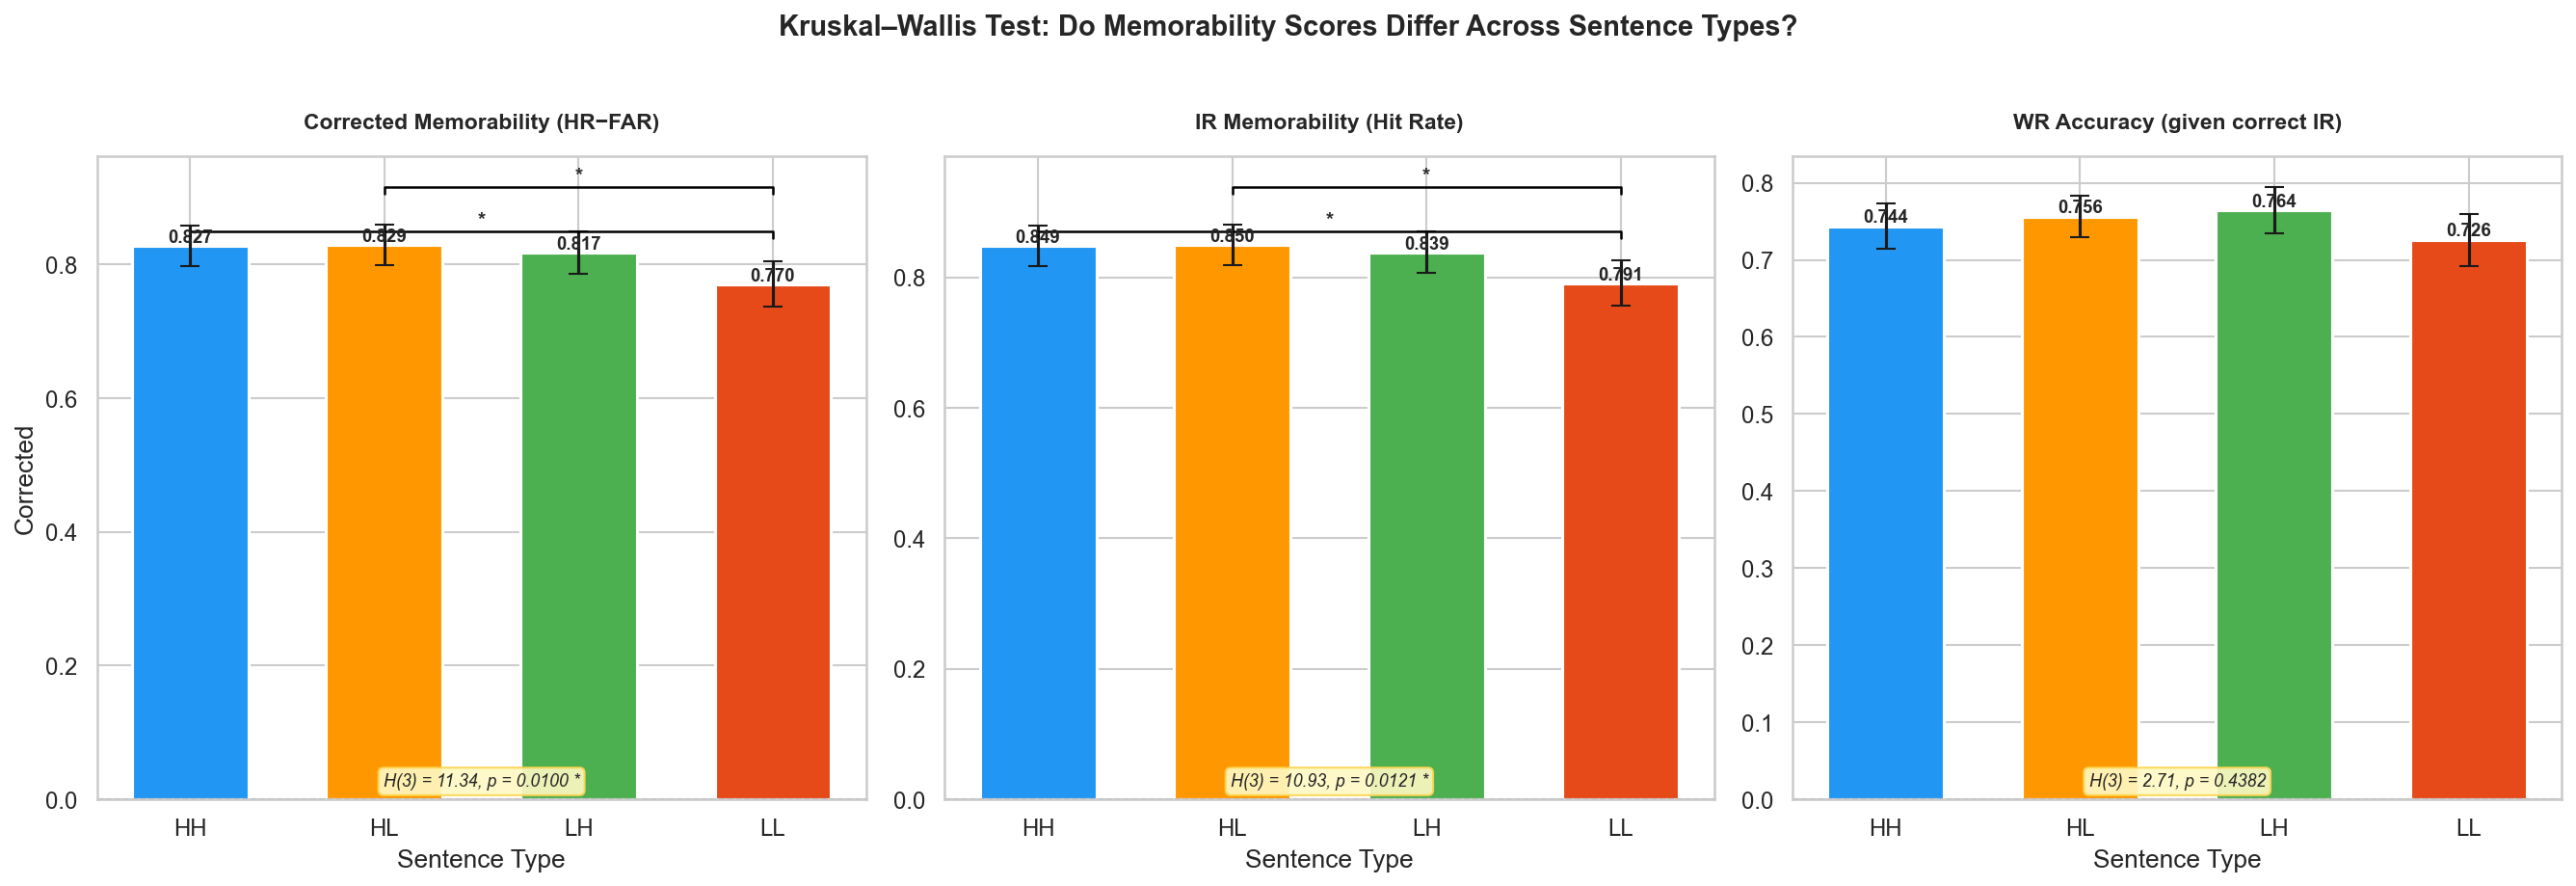

In [ ]:

def add_significance_brackets(ax, pairs_df, x_labels, y_values, y_offset=0.02):
    """Draw significance brackets on a bar chart for significant pairs."""
    if pairs_df is None:
        return
    sig_pairs = pairs_df[pairs_df["sig"] != "ns"].copy()
    if len(sig_pairs) == 0:
        return

    label_to_x = {lab: i for i, lab in enumerate(x_labels)}
    y_max = max(y_values) + y_offset
    step = (max(y_values) - min(max(y_values) * 0.3, 0)) * 0.08

    for idx, (_, row) in enumerate(sig_pairs.iterrows()):
        g1, g2 = row["Pair"].split(" vs ")
        x1, x2 = label_to_x[g1], label_to_x[g2]
        y_bar = y_max + step * idx
        ax.plot([x1, x1, x2, x2], [y_bar - step * 0.15, y_bar, y_bar, y_bar - step * 0.15],
                color="black", lw=1.2)
        ax.text((x1 + x2) / 2, y_bar + step * 0.05, row["sig"],
                ha="center", va="bottom", fontsize=10, fontweight="bold")

# ── Build the 3-panel figure ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_specs = [
    ("Corrected Memorability (HR−FAR)", part_corr, "corrected"),
    ("IR Memorability (Hit Rate)",      part_ir_kw, "hit_rate"),
    ("WR Accuracy (given correct IR)",  part_wr_kw, "wr_accuracy_given_ir"),
]

for i, (title, df_long, col) in enumerate(plot_specs):
    ax = axes[i]
    agg = (df_long.groupby("sent_type")[col]
           .agg(["mean", "sem"]).reindex(TYPE_ORDER))

    bars = ax.bar(TYPE_ORDER, agg["mean"],
                  yerr=agg["sem"] * 1.96, capsize=5,
                  color=[TYPE_PALETTE[t] for t in TYPE_ORDER],
                  edgecolor="white", linewidth=1.5, width=0.6)

    for b, t in zip(bars, TYPE_ORDER):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
                f"{agg.loc[t, 'mean']:.3f}", ha="center", fontsize=9, fontweight="bold")

    # Kruskal–Wallis annotation
    kw = kw_results[title]
    kw_text = f"H(3) = {kw['H']:.2f}, p = {kw['p']:.4f}"
    if kw["significant"]:
        kw_text += " *"
    ax.text(0.5, 0.02, kw_text, transform=ax.transAxes,
            ha="center", fontsize=8.5, fontstyle="italic",
            bbox=dict(boxstyle="round,pad=0.3", fc="#FFF9C4", ec="#FFD54F", alpha=0.9))

    # Significance brackets
    add_significance_brackets(ax, posthoc_results[title], TYPE_ORDER, agg["mean"].values)

    ax.set_ylabel(col.replace("_", " ").title() if i == 0 else "")
    ax.set_xlabel("Sentence Type")
    ax.set_title(title, fontweight="bold", fontsize=11, pad=14)
    ax.axhline(0, color="grey", ls="--", lw=0.8)

fig.suptitle("Kruskal–Wallis Test: Do Memorability Scores Differ Across Sentence Types?",
             fontweight="bold", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "21_kruskal_wallis_all_measures.png"), bbox_inches="tight")
plt.show()

In [42]:
# ══════════════════════════════════════════════════════════════════════
# 16d. Kruskal–Wallis by Voice (Active vs Passive) for each measure
# ══════════════════════════════════════════════════════════════════════
from scipy.stats import mannwhitneyu as mwu

print("=" * 70)
print("  MANN–WHITNEY U TEST — Voice Effect (Active vs Passive)")
print("=" * 70)

# Participant-level means per voice
voice_tests = {
    "Corrected Memorability": (
        cond_df.groupby(["participant_ID", "voice"])["corrected"].mean().reset_index(),
        "corrected"
    ),
    "IR Memorability": (
        cond_df.groupby(["participant_ID", "voice"])["hit_rate"].mean().reset_index(),
        "hit_rate"
    ),
    "WR Accuracy (given correct IR)": (
        wr_ir_df.groupby(["participant_ID", "voice"])["wr_accuracy_given_ir"].mean().reset_index(),
        "wr_accuracy_given_ir"
    ),
}

voice_mw_results = {}
for name, (df_long, col) in voice_tests.items():
    active  = df_long[df_long["voice"] == "Active"][col].values
    passive = df_long[df_long["voice"] == "Passive"][col].values
    U, p = mwu(active, passive, alternative="two-sided")
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    verdict = "✅ SIGNIFICANT" if p < 0.05 else "❌ Not significant"
    voice_mw_results[name] = {"U": U, "p": p, "sig": sig}

    a_mean, p_mean = active.mean(), passive.mean()
    print(f"\n  📊 {name}")
    print(f"     Active mean = {a_mean:.4f},  Passive mean = {p_mean:.4f}")
    print(f"     U = {U:.1f},  p = {p:.6f}  →  {verdict} ({sig})")

print("\n" + "=" * 70)

  MANN–WHITNEY U TEST — Voice Effect (Active vs Passive)

  📊 Corrected Memorability
     Active mean = 0.8068,  Passive mean = 0.8154
     U = 5830.5,  p = 0.362941  →  ❌ Not significant (ns)

  📊 IR Memorability
     Active mean = 0.8279,  Passive mean = 0.8365
     U = 5852.0,  p = 0.383878  →  ❌ Not significant (ns)

  📊 WR Accuracy (given correct IR)
     Active mean = 0.7643,  Passive mean = 0.7287
     U = 7162.0,  p = 0.065886  →  ❌ Not significant (ns)



In [43]:
# ══════════════════════════════════════════════════════════════════════
# 16e. LaTeX Summary Table — All Statistical Tests
# ══════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  SUMMARY OF ALL STATISTICAL TESTS")
print("=" * 70)

# Omnibus table
print("\n── Kruskal–Wallis (Sentence Type Effect) ──")
print(f"{'Measure':<40s} {'H(3)':>8s} {'p-value':>10s} {'Sig':>5s}")
print("─" * 65)
for name, res in kw_results.items():
    sig = "Yes" if res["significant"] else "No"
    print(f"  {name:<38s} {res['H']:>8.3f} {res['p']:>10.6f} {sig:>5s}")

# Voice table
print(f"\n── Mann–Whitney U (Voice Effect) ──")
print(f"{'Measure':<40s} {'U':>10s} {'p-value':>10s} {'Sig':>5s}")
print("─" * 67)
for name, res in voice_mw_results.items():
    sig_str = res["sig"]
    print(f"  {name:<38s} {res['U']:>10.1f} {res['p']:>10.6f} {sig_str:>5s}")

# ── LaTeX table ──
latex_kw_rows = []
for name, res in kw_results.items():
    short = name.split("(")[0].strip()
    sig = "Yes" if res["significant"] else "No"
    latex_kw_rows.append(f"    {short} & {res['H']:.3f} & {res['p']:.6f} & {sig} \\\\")

latex_voice_rows = []
for name, res in voice_mw_results.items():
    short = name.split("(")[0].strip()
    latex_voice_rows.append(f"    {short} & {res['U']:.1f} & {res['p']:.6f} & {res['sig']} \\\\")

latex_table = r"""\begin{table}[h]
\centering
\caption{Non-parametric statistical tests for sentence memorability}
\label{tab:stats}

\vspace{0.5em}
\textbf{(a) Kruskal--Wallis: Sentence Type Effect (HH, HL, LH, LL)}
\vspace{0.3em}

\begin{tabular}{lccc}
\toprule
Measure & $H(3)$ & $p$-value & Significant \\
\midrule
""" + "\n".join(latex_kw_rows) + r"""
\bottomrule
\end{tabular}

\vspace{1em}
\textbf{(b) Mann--Whitney U: Voice Effect (Active vs Passive)}
\vspace{0.3em}

\begin{tabular}{lccc}
\toprule
Measure & $U$ & $p$-value & Sig. \\
\midrule
""" + "\n".join(latex_voice_rows) + r"""
\bottomrule
\end{tabular}
\end{table}"""

print("\n\n── LaTeX (copy-paste ready) ──\n")
print(latex_table)

  SUMMARY OF ALL STATISTICAL TESTS

── Kruskal–Wallis (Sentence Type Effect) ──
Measure                                      H(3)    p-value   Sig
─────────────────────────────────────────────────────────────────
  Corrected Memorability (HR−FAR)          11.339   0.010025   Yes
  IR Memorability (Hit Rate)               10.927   0.012126   Yes
  WR Accuracy (given correct IR)            2.712   0.438172    No

── Mann–Whitney U (Voice Effect) ──
Measure                                           U    p-value   Sig
───────────────────────────────────────────────────────────────────
  Corrected Memorability                     5830.5   0.362941    ns
  IR Memorability                            5852.0   0.383878    ns
  WR Accuracy (given correct IR)             7162.0   0.065886    ns


── LaTeX (copy-paste ready) ──

\begin{table}[h]
\centering
\caption{Non-parametric statistical tests for sentence memorability}
\label{tab:stats}

\vspace{0.5em}
\textbf{(a) Kruskal--Wallis: Sentence Ty